## 01. IMPORT LIBRARIES

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## 02.  FILE LOCATIONS

In [9]:
PROJECT_ROOT = Path(
    r"C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor"
)

FEATURES_DIR = PROJECT_ROOT / "Data" / "Features"

HISTORICAL_FEATURES_PATH = (
    FEATURES_DIR / "historical_model_features.csv"
)

PREDICTION_FEATURES_PATH = (
    FEATURES_DIR / "prediction_target_features.csv"
)

print("=" * 80)
print("EDA DATASET LOCATIONS")
print("=" * 80)

print("\nHistorical modelling dataset:")
print(HISTORICAL_FEATURES_PATH)
print("Exists:", HISTORICAL_FEATURES_PATH.exists())

print("\nPrediction-target dataset:")
print(PREDICTION_FEATURES_PATH)
print("Exists:", PREDICTION_FEATURES_PATH.exists())

EDA DATASET LOCATIONS

Historical modelling dataset:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Data\Features\historical_model_features.csv
Exists: True

Prediction-target dataset:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Data\Features\prediction_target_features.csv
Exists: True


## 03. LOADING THE DATASET

In [10]:
eda_movies = pd.read_csv(
    HISTORICAL_FEATURES_PATH,
    low_memory=False
)

print("=" * 80)
print("HISTORICAL FEATURE DATASET LOADED")
print("=" * 80)

print(f"\nRows:    {eda_movies.shape[0]:,}")
print(f"Columns: {eda_movies.shape[1]:,}")

print("\nFirst 5 rows:")
display(eda_movies.head())

HISTORICAL FEATURE DATASET LOADED

Rows:    7,479
Columns: 17

First 5 rows:


,title,release_date,log_budget,release_year,release_month,release_quarter,holiday_release,director_prior_films,director_prior_avg_gross,star_prior_films,star_prior_avg_gross,company_prior_films,company_prior_avg_gross,primary_genre,release_season,worldwide_box_office,log_worldwide_box_office
0,The Shining,1980-06-13,16.759950,1980,6.0,2.0,0,0,NaN,0,NaN,0,NaN,Unknown,summer,46998772.0,17.665632
1,The Blue Lagoon,1980-07-02,15.319588,1980,7.0,3.0,0,0,NaN,0,NaN,0,NaN,Unknown,summer,58853106.0,17.890555
2,Star Wars: Episode V - The Empire Strikes Back,1980-06-20,16.705882,1980,6.0,2.0,0,0,NaN,0,NaN,0,NaN,Unknown,summer,538375067.0,20.104066
3,Airplane!,1980-07-02,15.068274,1980,7.0,3.0,0,0,NaN,0,NaN,0,NaN,Unknown,summer,83453539.0,18.239801
4,Caddyshack,1980-07-25,15.607270,1980,7.0,3.0,0,0,NaN,0,NaN,0,NaN,Unknown,summer,39846344.0,17.500541


## 04. STRUCTURAL AUDIT

In [11]:
print("=" * 80)
print("INITIAL STRUCTURAL AUDIT")
print("=" * 80)

print(f"\nDataset shape:")
print(eda_movies.shape)

print("\nDuplicate rows:")
print(eda_movies.duplicated().sum())

print("\nColumn names:")
for i, column in enumerate(eda_movies.columns, start=1):
    print(f"{i:>3}. {column}")

print("\nData types:")
display(
    eda_movies.dtypes
        .astype(str)
        .reset_index()
        .rename(
            columns={
                "index": "column",
                0: "dtype"
            }
        )
)

INITIAL STRUCTURAL AUDIT

Dataset shape:
(7479, 17)

Duplicate rows:
0

Column names:
  1. title
  2. release_date
  3. log_budget
  4. release_year
  5. release_month
  6. release_quarter
  7. holiday_release
  8. director_prior_films
  9. director_prior_avg_gross
 10. star_prior_films
 11. star_prior_avg_gross
 12. company_prior_films
 13. company_prior_avg_gross
 14. primary_genre
 15. release_season
 16. worldwide_box_office
 17. log_worldwide_box_office

Data types:


,column,dtype
0,title,object
1,release_date,object
2,log_budget,float64
3,release_year,int64
4,release_month,float64
5,release_quarter,float64
6,holiday_release,int64
7,director_prior_films,int64
8,director_prior_avg_gross,float64
9,star_prior_films,int64


## 05. MISSING VALUE OVERVIEW

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": eda_movies.isna().sum(),
    "missing_percent": (
        eda_movies.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values(
        by="missing_percent",
        ascending=False
    )
)

print("=" * 80)
print("MISSING VALUE SUMMARY")
print("=" * 80)

display(
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
)

MISSING VALUE SUMMARY


,missing_count,missing_percent
director_prior_avg_gross,2872,38.40
star_prior_avg_gross,2802,37.46
company_prior_avg_gross,2480,33.16
log_budget,2043,27.32
release_quarter,49,0.66
release_month,49,0.66
release_date,49,0.66


## 06. NUMERICAL SUMMARY

In [12]:
numeric_columns = eda_movies.select_dtypes(
    include=np.number
).columns.tolist()

print("=" * 80)
print("NUMERICAL FEATURE SUMMARY")
print("=" * 80)

print(f"\nNumber of numerical columns: {len(numeric_columns)}")

display(
    eda_movies[numeric_columns]
    .describe()
    .T
)

NUMERICAL FEATURE SUMMARY

Number of numerical columns: 13


,count,mean,std,min,25%,50%,75%,max
log_budget,5436.0,1.678020e+01,1.275515e+00,8.699681,1.611810e+01,1.686003e+01,1.762217e+01,1.969044e+01
release_year,7479.0,2.000658e+03,1.105481e+01,1980.000000,1.991000e+03,2.001000e+03,2.010000e+03,2.020000e+03
release_month,7430.0,6.583715e+00,3.435294e+00,1.000000,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
release_quarter,7430.0,2.531359e+00,1.123915e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00
holiday_release,7479.0,1.607167e-01,3.672940e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
director_prior_films,7479.0,2.469047e+00,3.728708e+00,0.000000,0.000000e+00,1.000000e+00,3.000000e+00,3.700000e+01
director_prior_avg_gross,4607.0,7.056775e+07,1.100877e+08,1605.000000,1.080996e+07,3.153640e+07,8.394742e+07,1.159445e+09
star_prior_films,7479.0,4.060168e+00,6.103929e+00,0.000000,0.000000e+00,1.000000e+00,6.000000e+00,4.200000e+01
star_prior_avg_gross,4677.0,7.759012e+07,1.184852e+08,2368.000000,1.567273e+07,4.402162e+07,1.011831e+08,2.847246e+09
company_prior_films,7479.0,4.369715e+01,7.818602e+01,0.000000,0.000000e+00,4.000000e+00,4.700000e+01,3.740000e+02


## 07. TRACK RECORD MISSING AUDIT

In [13]:
track_record_features = {
    "Director": (
        "director_prior_films",
        "director_prior_avg_gross"
    ),
    "Star": (
        "star_prior_films",
        "star_prior_avg_gross"
    ),
    "Company": (
        "company_prior_films",
        "company_prior_avg_gross"
    )
}

missingness_audit = []

for entity, (count_col, avg_col) in track_record_features.items():

    zero_prior = eda_movies[count_col] == 0
    positive_prior = eda_movies[count_col] > 0
    missing_avg = eda_movies[avg_col].isna()

    missingness_audit.append({
        "entity": entity,
        "total_rows": len(eda_movies),
        "zero_prior_films": zero_prior.sum(),
        "missing_avg_gross": missing_avg.sum(),
        "missing_when_zero_prior": (
            zero_prior & missing_avg
        ).sum(),
        "missing_when_prior_positive": (
            positive_prior & missing_avg
        ).sum(),
        "avg_present_when_zero_prior": (
            zero_prior & ~missing_avg
        ).sum()
    })

missingness_audit = pd.DataFrame(missingness_audit)

print("=" * 80)
print("TRACK-RECORD MISSINGNESS AUDIT")
print("=" * 80)

display(missingness_audit)

TRACK-RECORD MISSINGNESS AUDIT


,entity,total_rows,zero_prior_films,missing_avg_gross,missing_when_zero_prior,missing_when_prior_positive,avg_present_when_zero_prior
0,Director,7479,2872,2872,2872,0,0
1,Star,7479,2802,2802,2802,0,0
2,Company,7479,2480,2480,2480,0,0


## 08. BOX OFFICE TARGET DISTRIBUTION

In [14]:
target = eda_movies["worldwide_box_office"].dropna()

print("=" * 80)
print("WORLDWIDE BOX-OFFICE TARGET ANALYSIS")
print("=" * 80)

print(f"\nMovies: {len(target):,}")

print(f"\nMean:   ${target.mean():,.0f}")
print(f"Median: ${target.median():,.0f}")
print(f"Std:    ${target.std():,.0f}")
print(f"Min:    ${target.min():,.0f}")
print(f"Max:    ${target.max():,.0f}")

print(f"\nSkewness: {target.skew():.3f}")

target_percentiles = target.quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50,
     0.75, 0.90, 0.95, 0.99]
)

target_percentiles = pd.DataFrame({
    "percentile": [
        "1%", "5%", "10%", "25%", "50%",
        "75%", "90%", "95%", "99%"
    ],
    "worldwide_box_office": target_percentiles.values
})

display(target_percentiles)

WORLDWIDE BOX-OFFICE TARGET ANALYSIS

Movies: 7,479

Mean:   $78,500,541
Median: $20,205,757
Std:    $165,725,124
Min:    $309
Max:    $2,847,246,203

Skewness: 5.314


,percentile,worldwide_box_office
0,1%,2.203108e+04
1,5%,2.677402e+05
2,10%,8.667822e+05
3,25%,4.532056e+06
4,50%,2.020576e+07
5,75%,7.601669e+07
6,90%,2.090678e+08
7,95%,3.528074e+08
8,99%,8.566930e+08


## 09. RAW VS. LOG BOX-OFFICE DISTRIBUTION

TARGET VISUALISATION CHECK

Valid raw box-office values: 7,479
Valid log box-office values: 7,479

Raw minimum: $309
Raw maximum: $2,847,246,203


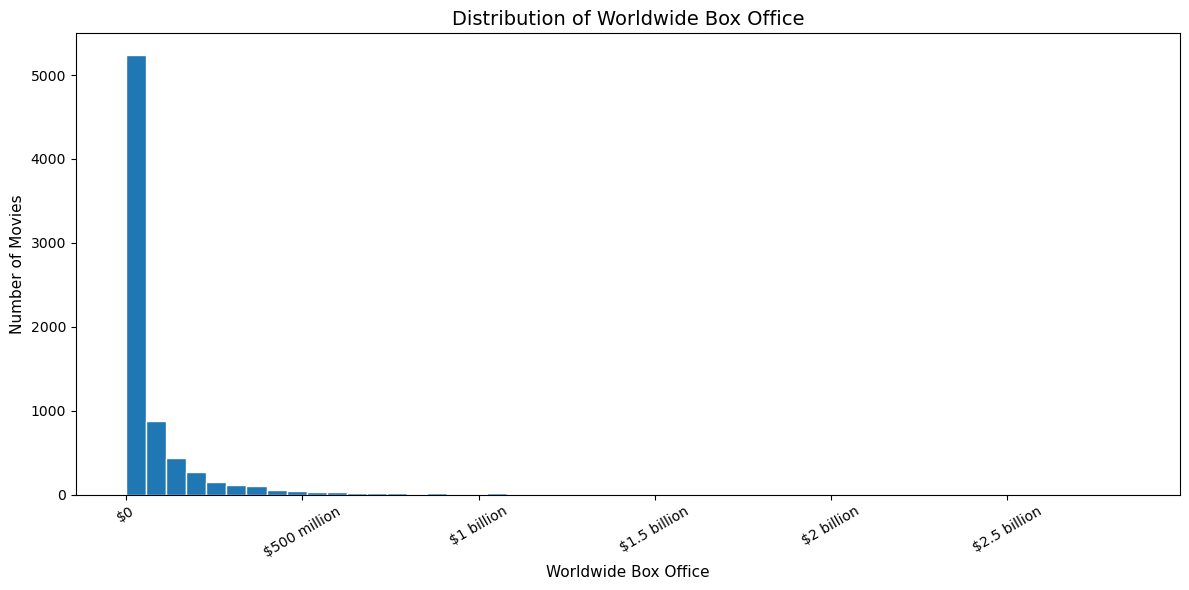

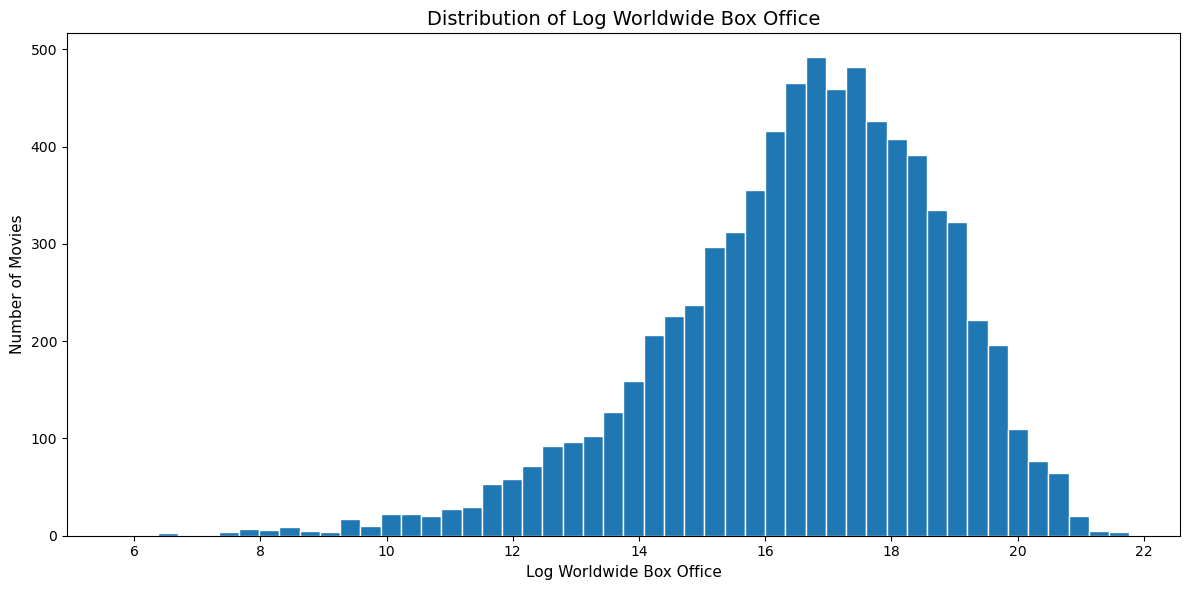

In [19]:
from matplotlib.ticker import FuncFormatter
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Financial axis formatter
# ------------------------------------------------------------

def format_money(value, position=None):

    if value == 0:
        return "$0"

    if abs(value) >= 1_000_000_000:
        amount = value / 1_000_000_000
        return f"${amount:g} billion"

    if abs(value) >= 1_000_000:
        amount = value / 1_000_000
        return f"${amount:g} million"

    if abs(value) >= 1_000:
        amount = value / 1_000
        return f"${amount:g} thousand"

    return f"${value:g}"


# ------------------------------------------------------------
# Prepare target variables
# ------------------------------------------------------------

raw_box_office = pd.to_numeric(
    eda_movies["worldwide_box_office"],
    errors="coerce"
).dropna()

log_box_office = pd.to_numeric(
    eda_movies["log_worldwide_box_office"],
    errors="coerce"
).dropna()


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("=" * 80)
print("TARGET VISUALISATION CHECK")
print("=" * 80)

print(f"\nValid raw box-office values: {len(raw_box_office):,}")
print(f"Valid log box-office values: {len(log_box_office):,}")

print(f"\nRaw minimum: ${raw_box_office.min():,.0f}")
print(f"Raw maximum: ${raw_box_office.max():,.0f}")


if raw_box_office.empty:
    raise ValueError(
        "worldwide_box_office contains no valid numeric values."
    )

if log_box_office.empty:
    raise ValueError(
        "log_worldwide_box_office contains no valid numeric values."
    )


# ------------------------------------------------------------
# Raw worldwide box-office distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    raw_box_office,
    bins=50,
    edgecolor="white"
)

ax.set_title(
    "Distribution of Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Worldwide Box Office",
    fontsize=11
)

ax.set_ylabel(
    "Number of Movies",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Log worldwide box-office distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    log_box_office,
    bins=50,
    edgecolor="white"
)

ax.set_title(
    "Distribution of Log Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Log Worldwide Box Office",
    fontsize=11
)

ax.set_ylabel(
    "Number of Movies",
    fontsize=11
)

plt.tight_layout()
plt.show()

## 10. EXPLORE POSSIBLE BLOCKBUSTER DEFINITIONS

In [16]:
box_office = eda_movies["worldwide_box_office"]

thresholds = {
    "$100M+": 100_000_000,
    "$250M+": 250_000_000,
    "$500M+": 500_000_000,
    "$1B+": 1_000_000_000,
    "Top 20%": box_office.quantile(0.80),
    "Top 10%": box_office.quantile(0.90),
    "Top 5%": box_office.quantile(0.95)
}

threshold_results = []

for label, threshold in thresholds.items():

    blockbuster_count = (
        box_office >= threshold
    ).sum()

    blockbuster_percent = (
        blockbuster_count / len(box_office)
    ) * 100

    threshold_results.append({
        "definition": label,
        "threshold_usd": threshold,
        "blockbuster_movies": blockbuster_count,
        "non_blockbuster_movies": (
            len(box_office) - blockbuster_count
        ),
        "blockbuster_percent": blockbuster_percent
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results["threshold_usd"] = (
    threshold_results["threshold_usd"]
    .round(0)
    .astype("int64")
)

threshold_results["blockbuster_percent"] = (
    threshold_results["blockbuster_percent"]
    .round(2)
)

print("=" * 80)
print("BLOCKBUSTER DEFINITION EXPLORATION")
print("=" * 80)

display(threshold_results)

BLOCKBUSTER DEFINITION EXPLORATION


,definition,threshold_usd,blockbuster_movies,non_blockbuster_movies,blockbuster_percent
0,$100M+,100000000,1525,5954,20.39
1,$250M+,250000000,594,6885,7.94
2,$500M+,500000000,207,7272,2.77
3,$1B+,1000000000,48,7431,0.64
4,Top 20%,101848179,1496,5983,20.00
5,Top 10%,209067794,748,6731,10.00
6,Top 5%,352807395,374,7105,5.00


## 11. RECONSTRUCT AND RELEASE-TIMING ANALYSIS

In [25]:
# Reverse the log1p transformation used during Feature Engineering
eda_movies["budget_usd"] = np.expm1(
    eda_movies["log_budget"]
)

print("=" * 80)
print("BUDGET RECONSTRUCTION CHECK")
print("=" * 80)

print(
    f"\nMovies with budget data: "
    f"{eda_movies['budget_usd'].notna().sum():,}"
)

print(
    f"Movies without budget data: "
    f"{eda_movies['budget_usd'].isna().sum():,}"
)

print(
    f"\nMinimum budget: "
    f"${eda_movies['budget_usd'].min():,.0f}"
)

print(
    f"Median budget: "
    f"${eda_movies['budget_usd'].median():,.0f}"
)

print(
    f"Mean budget: "
    f"${eda_movies['budget_usd'].mean():,.0f}"
)

print(
    f"Maximum budget: "
    f"${eda_movies['budget_usd'].max():,.0f}"
)

BUDGET RECONSTRUCTION CHECK

Movies with budget data: 5,436
Movies without budget data: 2,043

Minimum budget: $6,000
Median budget: $21,000,000
Mean budget: $35,938,638
Maximum budget: $356,000,000


## 12. BUDGET DISTRIBUTION

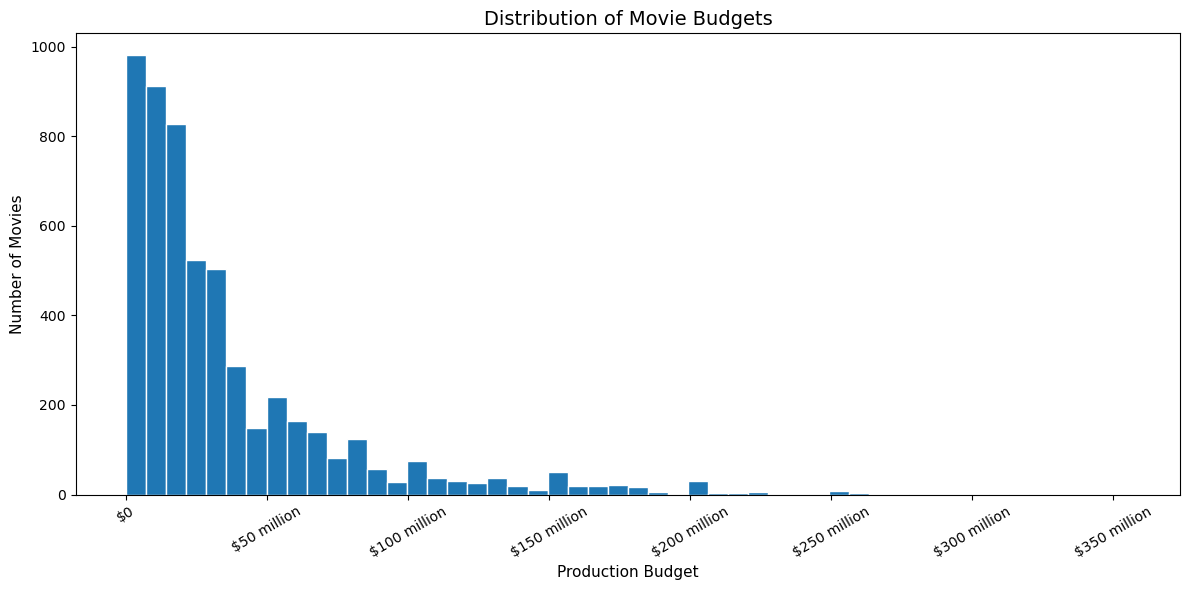

In [26]:
budget_data = eda_movies["budget_usd"].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    budget_data,
    bins=50,
    edgecolor="white"
)

ax.set_title(
    "Distribution of Movie Budgets",
    fontsize=14
)

ax.set_xlabel(
    "Production Budget",
    fontsize=11
)

ax.set_ylabel(
    "Number of Movies",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 13. BUDGET VS. WORLWIDE BOX OFFICE

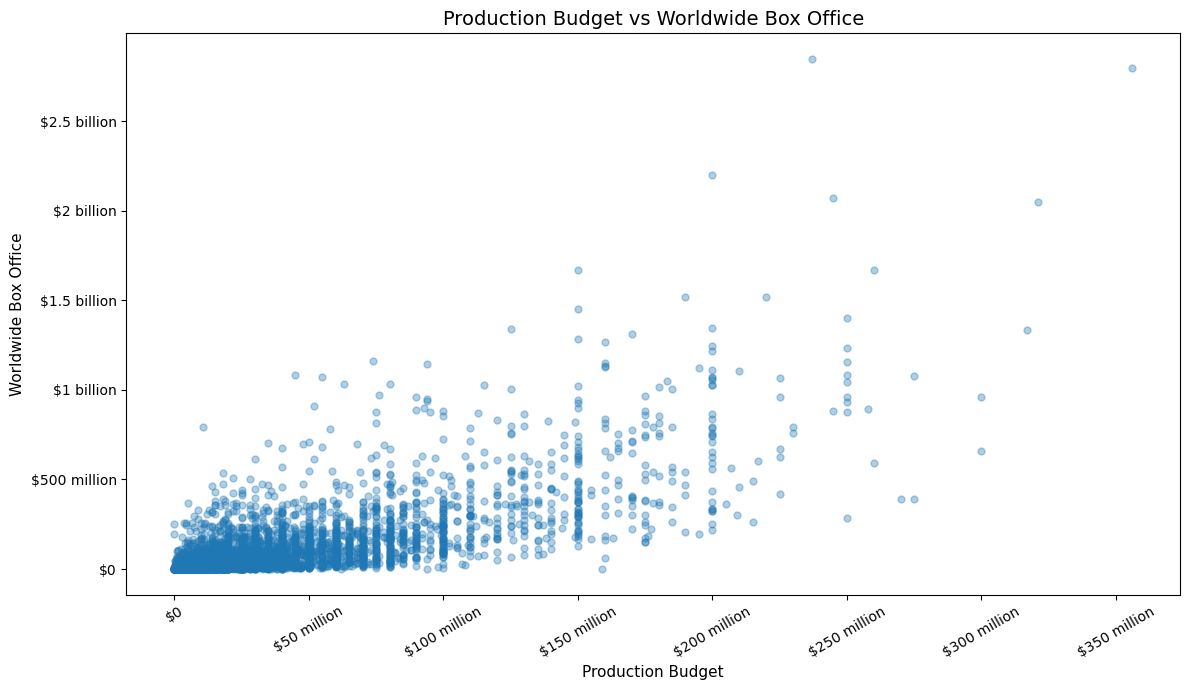

Budget ↔ Worldwide Box Office correlation: 0.740


In [27]:
budget_revenue_data = (
    eda_movies[
        [
            "budget_usd",
            "worldwide_box_office"
        ]
    ]
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    budget_revenue_data["budget_usd"],
    budget_revenue_data["worldwide_box_office"],
    alpha=0.35,
    s=25
)

ax.set_title(
    "Production Budget vs Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Production Budget",
    fontsize=11
)

ax.set_ylabel(
    "Worldwide Box Office",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


budget_revenue_corr = (
    budget_revenue_data[
        [
            "budget_usd",
            "worldwide_box_office"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Budget ↔ Worldwide Box Office correlation: "
    f"{budget_revenue_corr:.3f}"
)

## 14. REVENUE PERFORMANCE BY RELEASE MONTH

RELEASE MONTH PERFORMANCE


,month,movie_count,median_box_office,mean_box_office
0,Jan,581,22687639.0,5.165745e+07
1,Feb,591,21150265.0,5.613883e+07
2,Mar,666,16291116.5,6.324348e+07
3,Apr,627,14659448.0,5.299571e+07
4,May,556,17059990.5,1.213513e+08
5,Jun,552,40100685.5,1.326667e+08
6,Jul,569,35739755.0,1.240036e+08
7,Aug,722,18106207.5,5.172716e+07
8,Sep,637,11665465.0,3.978820e+07
9,Oct,727,15448043.0,4.626438e+07


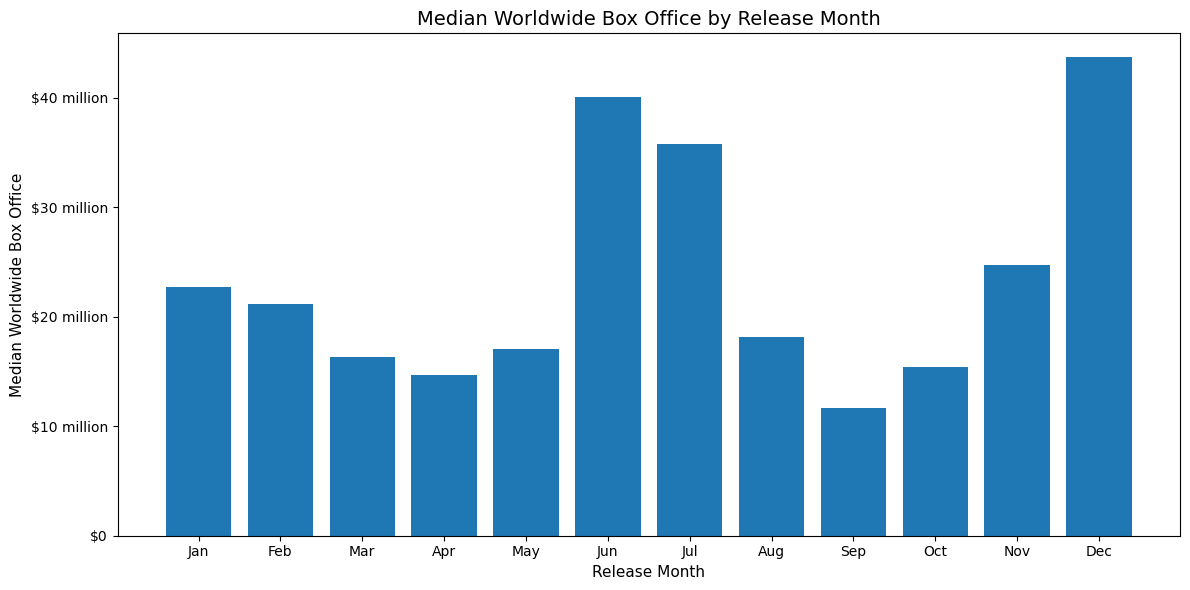

In [28]:
month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

monthly_performance = (
    eda_movies
    .dropna(
        subset=[
            "release_month",
            "worldwide_box_office"
        ]
    )
    .groupby("release_month")
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
)

monthly_performance["month"] = (
    monthly_performance["release_month"]
    .map(month_names)
)

print("=" * 80)
print("RELEASE MONTH PERFORMANCE")
print("=" * 80)

display(
    monthly_performance[
        [
            "month",
            "movie_count",
            "median_box_office",
            "mean_box_office"
        ]
    ]
)


fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    monthly_performance["month"],
    monthly_performance["median_box_office"]
)

ax.set_title(
    "Median Worldwide Box Office by Release Month",
    fontsize=14
)

ax.set_xlabel(
    "Release Month",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 15. HOLIDAY VS. NON-HOLIDAY RELEASES

,release_type,movie_count,median_box_office,mean_box_office
0,Non-Holiday Release,6277,18689058.0,7.108192e+07
1,Holiday Release,1202,34981842.5,1.172415e+08


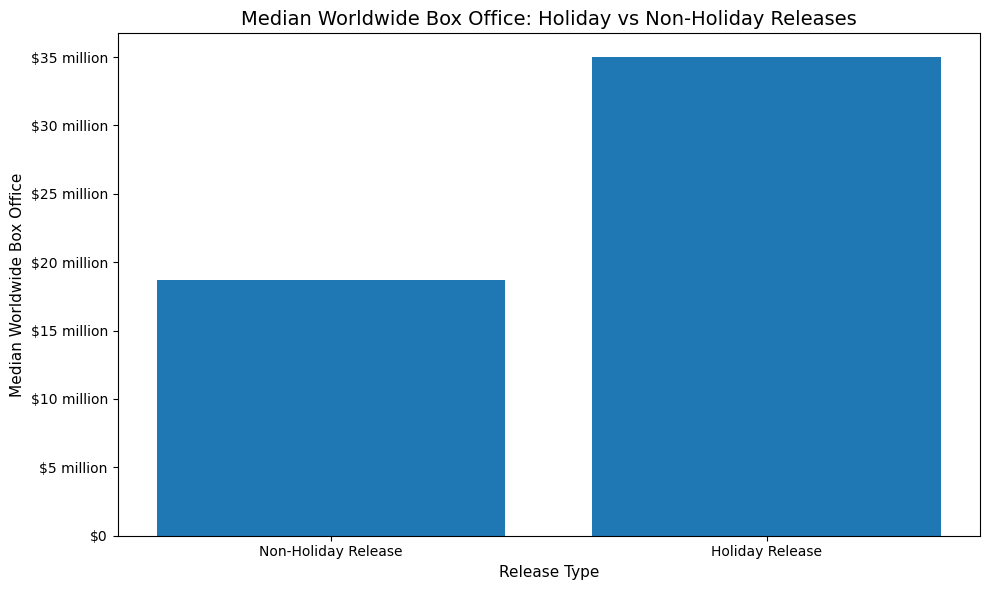

In [29]:
holiday_performance = (
    eda_movies
    .groupby("holiday_release")
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
)

holiday_performance["release_type"] = (
    holiday_performance["holiday_release"]
    .map({
        0: "Non-Holiday Release",
        1: "Holiday Release"
    })
)

display(
    holiday_performance[
        [
            "release_type",
            "movie_count",
            "median_box_office",
            "mean_box_office"
        ]
    ]
)


fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    holiday_performance["release_type"],
    holiday_performance["median_box_office"]
)

ax.set_title(
    "Median Worldwide Box Office: Holiday vs Non-Holiday Releases",
    fontsize=14
)

ax.set_xlabel(
    "Release Type",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 16A. VAILDATE PRIMARY GENRE

In [39]:

print("=" * 80)
print("PRIMARY GENRE VALIDATION")
print("=" * 80)

print(f"\nTotal rows: {len(eda_movies):,}")

print(
    f"Unique genre values: "
    f"{eda_movies['primary_genre'].nunique(dropna=False):,}"
)

print("\nGenre counts:")
print(
    eda_movies["primary_genre"]
    .value_counts(dropna=False)
)

print("\nGenre percentages:")
print(
    (
        eda_movies["primary_genre"]
        .value_counts(
            normalize=True,
            dropna=False
        )
        * 100
    ).round(2)
)

print("\nSample values:")
print(
    eda_movies["primary_genre"]
    .head(20)
    .tolist()
)

PRIMARY GENRE VALIDATION

Total rows: 7,479
Unique genre values: 1

Genre counts:
primary_genre
Unknown    7479
Name: count, dtype: int64

Genre percentages:
primary_genre
Unknown    100.0
Name: proportion, dtype: float64

Sample values:
['Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown']


## 16B. CHECK UPSTREAM GENRE DATA

In [40]:
CLEANED_MOVIES_PATH = (
    PROJECT_ROOT
    / "Data"
    / "Clean"
    / "cleaned_movies.csv"
)

cleaned_movies = pd.read_csv(
    CLEANED_MOVIES_PATH,
    low_memory=False
)

print("=" * 80)
print("UPSTREAM GENRE DATA CHECK")
print("=" * 80)

print("\nFile exists:")
print(CLEANED_MOVIES_PATH.exists())

print(f"\nRows: {len(cleaned_movies):,}")
print(f"Columns: {cleaned_movies.shape[1]:,}")

print("\nRelevant columns available:")

for column in [
    "name",
    "title",
    "year",
    "released",
    "release_date",
    "genre"
]:
    print(
        f"{column:<15} -> "
        f"{column in cleaned_movies.columns}"
    )

if "genre" in cleaned_movies.columns:

    print("\nMissing genre values:")
    print(
        cleaned_movies["genre"]
        .isna()
        .sum()
    )

    print("\nUnique genres:")
    print(
        cleaned_movies["genre"]
        .nunique(dropna=True)
    )

    print("\nTop genre counts:")
    print(
        cleaned_movies["genre"]
        .value_counts(dropna=False)
        .head(20)
    )

UPSTREAM GENRE DATA CHECK

File exists:
True

Rows: 7,668
Columns: 20

Relevant columns available:
name            -> True
title           -> False
year            -> True
released        -> True
release_date    -> False
genre           -> True

Missing genre values:
0

Unique genres:
19

Top genre counts:
genre
Comedy       2245
Action       1705
Drama        1518
Crime         551
Biography     443
Adventure     427
Animation     338
Horror        322
Fantasy        44
Mystery        20
Thriller       16
Family         11
Sci-Fi         10
Romance        10
Western         3
Musical         2
Music           1
History         1
Sport           1
Name: count, dtype: int64


## 16C. GENRE MATCHING AUDIT

In [43]:
def normalize_title(series):
    return (
        series
        .astype("string")
        .str.lower()
        .str.strip()
        .str.normalize("NFKD")
        .str.encode(
            "ascii",
            errors="ignore"
        )
        .str.decode("ascii")
        .str.replace(
            r"[^a-z0-9]+",
            " ",
            regex=True
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )


# ------------------------------------------------------------
# Prepare EDA dataset keys
# ------------------------------------------------------------

eda_genre_match = (
    eda_movies[
        [
            "title",
            "release_year"
        ]
    ]
    .copy()
)

eda_genre_match["title_normalized"] = (
    normalize_title(
        eda_genre_match["title"]
    )
)

eda_genre_match["year_normalized"] = (
    pd.to_numeric(
        eda_genre_match["release_year"],
        errors="coerce"
    )
    .astype("Int64")
)

eda_genre_match["match_key"] = (
    eda_genre_match["title_normalized"]
    + "||"
    + eda_genre_match["year_normalized"]
    .astype("string")
)


# ------------------------------------------------------------
# Prepare cleaned source keys
# ------------------------------------------------------------

source_genres = (
    cleaned_movies[
        [
            "name",
            "year",
            "genre"
        ]
    ]
    .copy()
)

source_genres["title_normalized"] = (
    normalize_title(
        source_genres["name"]
    )
)

source_genres["year_normalized"] = (
    pd.to_numeric(
        source_genres["year"],
        errors="coerce"
    )
    .astype("Int64")
)

source_genres["match_key"] = (
    source_genres["title_normalized"]
    + "||"
    + source_genres["year_normalized"]
    .astype("string")
)


# ------------------------------------------------------------
# Audit duplicate source keys
# ------------------------------------------------------------

source_key_counts = (
    source_genres["match_key"]
    .value_counts()
)

duplicate_source_keys = (
    source_key_counts > 1
).sum()

print("=" * 80)
print("GENRE MATCHING AUDIT")
print("=" * 80)

print(
    f"\nEDA rows: "
    f"{len(eda_genre_match):,}"
)

print(
    f"Source rows: "
    f"{len(source_genres):,}"
)

print(
    f"\nDuplicate title-year keys "
    f"in genre source: "
    f"{duplicate_source_keys:,}"
)


# ------------------------------------------------------------
# Keep only unambiguous source matches
# ------------------------------------------------------------

unique_keys = (
    source_key_counts[
        source_key_counts == 1
    ]
    .index
)

source_genres_unique = (
    source_genres[
        source_genres["match_key"]
        .isin(unique_keys)
    ][
        [
            "match_key",
            "genre"
        ]
    ]
)


genre_match_audit = (
    eda_genre_match
    .merge(
        source_genres_unique,
        on="match_key",
        how="left"
    )
)


matched_count = (
    genre_match_audit["genre"]
    .notna()
    .sum()
)

matched_percent = (
    matched_count
    / len(genre_match_audit)
    * 100
)

print(
    f"\nMovies successfully matched: "
    f"{matched_count:,}"
)

print(
    f"Match rate: "
    f"{matched_percent:.2f}%"
)

print(
    f"Unmatched movies: "
    f"{genre_match_audit['genre'].isna().sum():,}"
)

GENRE MATCHING AUDIT

EDA rows: 7,479
Source rows: 7,668

Duplicate title-year keys in genre source: 0

Movies successfully matched: 7,479
Match rate: 100.00%
Unmatched movies: 0


## 16D. REPAIR PRIMARY GENRE

In [45]:
# Preserve row count before repair
rows_before = len(eda_movies)

# Create lookup table
genre_lookup = (
    source_genres_unique[
        [
            "match_key",
            "genre"
        ]
    ]
    .rename(
        columns={
            "genre": "recovered_genre"
        }
    )
)

# Recreate matching key in EDA dataset
eda_movies["title_normalized"] = (
    normalize_title(
        eda_movies["title"]
    )
)

eda_movies["year_normalized"] = (
    pd.to_numeric(
        eda_movies["release_year"],
        errors="coerce"
    )
    .astype("Int64")
)

eda_movies["match_key"] = (
    eda_movies["title_normalized"]
    + "||"
    + eda_movies["year_normalized"]
    .astype("string")
)

# Merge recovered genre
eda_movies = (
    eda_movies
    .merge(
        genre_lookup,
        on="match_key",
        how="left"
    )
)

# Replace broken primary_genre values
eda_movies["primary_genre"] = (
    eda_movies["recovered_genre"]
)

# Remove temporary columns
eda_movies = (
    eda_movies
    .drop(
        columns=[
            "title_normalized",
            "year_normalized",
            "match_key",
            "recovered_genre"
        ]
    )
)

rows_after = len(eda_movies)

print("=" * 80)
print("PRIMARY GENRE REPAIR")
print("=" * 80)

print(f"\nRows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")

print(
    f"\nMissing genres after repair: "
    f"{eda_movies['primary_genre'].isna().sum():,}"
)

print(
    f"Unique genres after repair: "
    f"{eda_movies['primary_genre'].nunique():,}"
)

print("\nGenre counts:")
print(
    eda_movies["primary_genre"]
    .value_counts()
)

PRIMARY GENRE REPAIR

Rows before: 7,479
Rows after:  7,479

Missing genres after repair: 0
Unique genres after repair: 18

Genre counts:
primary_genre
Comedy       2192
Action       1673
Drama        1468
Crime         542
Biography     433
Adventure     420
Animation     335
Horror        307
Fantasy        43
Mystery        20
Thriller       12
Family         11
Sci-Fi          8
Romance         8
Western         3
Musical         2
Music           1
Sport           1
Name: count, dtype: int64


## 16E. VALIDATE AND SAVE GENRE REPAIR

In [46]:
print("=" * 80)
print("FINAL GENRE REPAIR VALIDATION")
print("=" * 80)

assert len(eda_movies) == 7479, (
    "Unexpected row-count change."
)

assert eda_movies["primary_genre"].isna().sum() == 0, (
    "Missing genre values remain."
)

assert eda_movies["primary_genre"].nunique() > 1, (
    "Genre repair failed."
)

assert (
    eda_movies["primary_genre"]
    .eq("Unknown")
    .sum()
    == 0
), "Unknown genre values remain."


# Save corrected historical feature dataset
eda_movies.to_csv(
    HISTORICAL_FEATURES_PATH,
    index=False
)

print("\nGenre repair validation passed.")

print(
    "\nCorrected dataset saved to:"
)

print(HISTORICAL_FEATURES_PATH)

print(
    f"\nUnique genres: "
    f"{eda_movies['primary_genre'].nunique()}"
)

FINAL GENRE REPAIR VALIDATION

Genre repair validation passed.

Corrected dataset saved to:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Data\Features\historical_model_features.csv

Unique genres: 18


## 16. GENRE REPRESENTATION

GENRE REPRESENTATION


,genre,movie_count,dataset_percent
0,Comedy,2192,29.31
1,Action,1673,22.37
2,Drama,1468,19.63
3,Crime,542,7.25
4,Biography,433,5.79
5,Adventure,420,5.62
6,Animation,335,4.48
7,Horror,307,4.10
8,Fantasy,43,0.57
9,Mystery,20,0.27


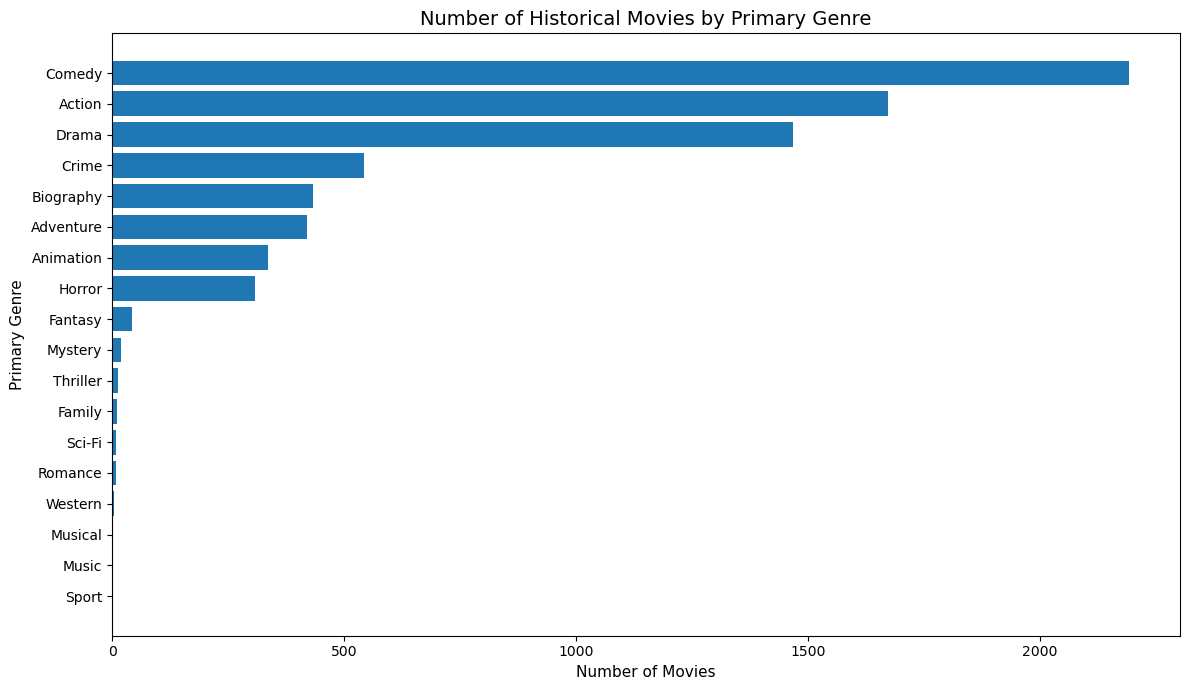

In [47]:
genre_counts = (
    eda_movies["primary_genre"]
    .value_counts(dropna=False)
    .rename_axis("genre")
    .reset_index(name="movie_count")
)

genre_counts["dataset_percent"] = (
    genre_counts["movie_count"]
    / len(eda_movies)
    * 100
).round(2)

print("=" * 80)
print("GENRE REPRESENTATION")
print("=" * 80)

display(genre_counts)


fig, ax = plt.subplots(figsize=(12, 7))

genre_plot = (
    genre_counts
    .dropna(subset=["genre"])
    .sort_values("movie_count")
)

ax.barh(
    genre_plot["genre"],
    genre_plot["movie_count"]
)

ax.set_title(
    "Number of Historical Movies by Primary Genre",
    fontsize=14
)

ax.set_xlabel(
    "Number of Movies",
    fontsize=11
)

ax.set_ylabel(
    "Primary Genre",
    fontsize=11
)

plt.tight_layout()
plt.show()

## 17. BOX-OFFICE PERFORMANCE BY GENRE

GENRE BOX-OFFICE PERFORMANCE


,primary_genre,movie_count,median_box_office,mean_box_office
2,Animation,335,139804348.0,2.392300e+08
0,Action,1673,51386477.0,1.455086e+08
1,Adventure,420,27989799.0,1.093252e+08
9,Horror,307,20471382.0,4.737241e+07
8,Fantasy,43,19595031.0,3.870933e+07
12,Mystery,20,19255503.5,1.011835e+08
3,Biography,433,18598607.0,4.787432e+07
4,Comedy,2192,16373597.0,4.433187e+07
5,Crime,542,12239344.5,3.940120e+07
16,Thriller,12,12105479.0,2.693526e+07


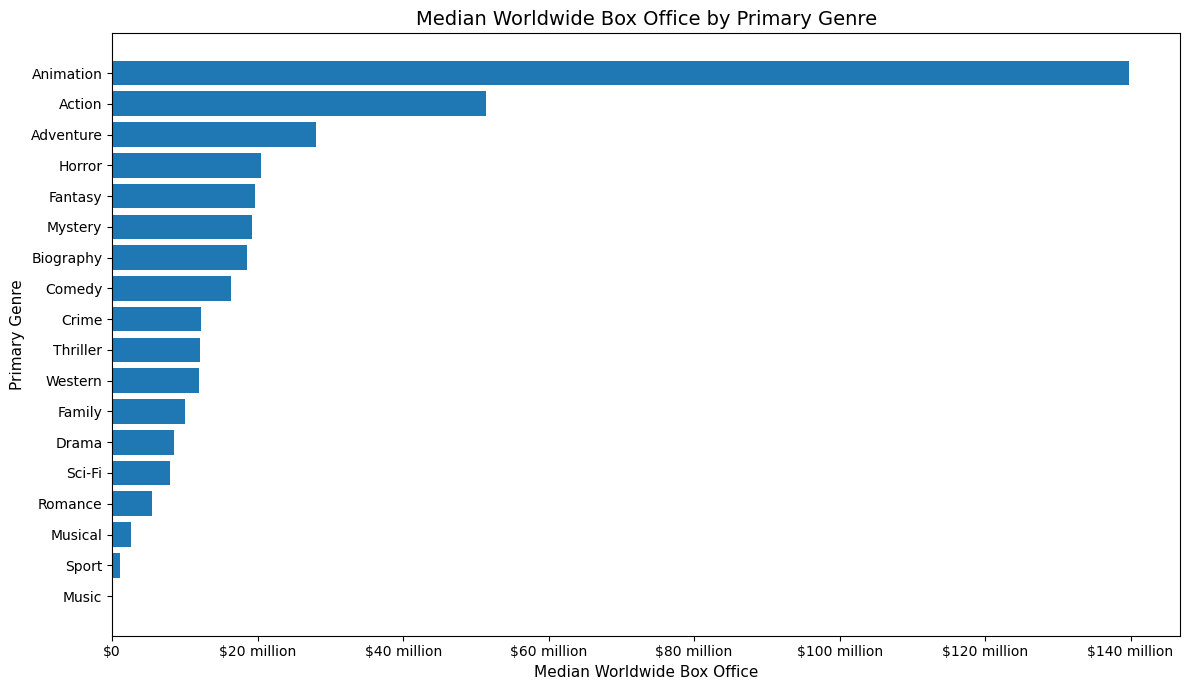

In [48]:
genre_performance = (
    eda_movies
    .dropna(
        subset=[
            "primary_genre",
            "worldwide_box_office"
        ]
    )
    .groupby("primary_genre")
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "median_box_office",
        ascending=False
    )
)

print("=" * 80)
print("GENRE BOX-OFFICE PERFORMANCE")
print("=" * 80)

display(genre_performance)


genre_plot = (
    genre_performance
    .sort_values("median_box_office")
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    genre_plot["primary_genre"],
    genre_plot["median_box_office"]
)

ax.set_title(
    "Median Worldwide Box Office by Primary Genre",
    fontsize=14
)

ax.set_xlabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.set_ylabel(
    "Primary Genre",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 18. DIRECTOR EXPERIENCE VS. BOX OFFICE



,director_experience_band,movie_count,median_box_office,mean_box_office
0,No Prior Films,2872,9879447.0,4.163840e+07
1,1–2 Prior Films,2227,22472631.0,7.766535e+07
2,3–5 Prior Films,1318,38560065.5,1.136016e+08
3,6–10 Prior Films,759,52090187.0,1.433672e+08
4,11+ Prior Films,303,56996304.0,1.188670e+08


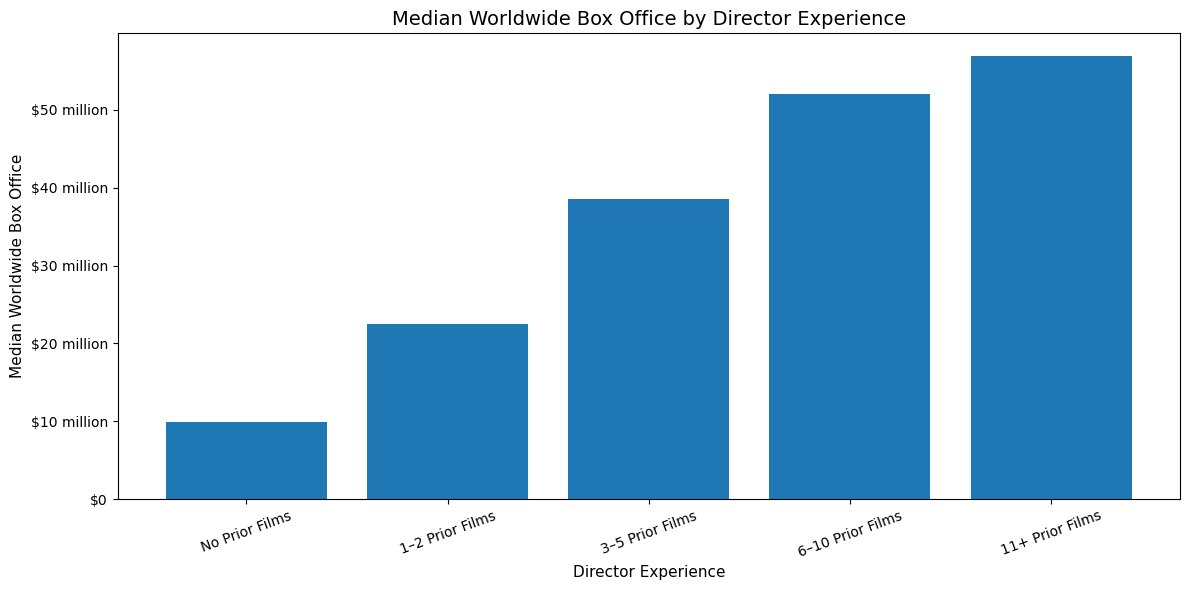

In [32]:
director_experience = eda_movies.copy()

director_experience["director_experience_band"] = pd.cut(
    director_experience["director_prior_films"],
    bins=[
        -1,
        0,
        2,
        5,
        10,
        np.inf
    ],
    labels=[
        "No Prior Films",
        "1–2 Prior Films",
        "3–5 Prior Films",
        "6–10 Prior Films",
        "11+ Prior Films"
    ]
)

director_performance = (
    director_experience
    .groupby(
        "director_experience_band",
        observed=True
    )
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
)

display(director_performance)


fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    director_performance["director_experience_band"].astype(str),
    director_performance["median_box_office"]
)

ax.set_title(
    "Median Worldwide Box Office by Director Experience",
    fontsize=14
)

ax.set_xlabel(
    "Director Experience",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 19. STAR EXPERIENCE VS. BOX-OFFICE

STAR EXPERIENCE PERFORMANCE


,star_experience_band,movie_count,median_box_office,mean_box_office
0,No Prior Films,2802,9095761.5,4.232954e+07
1,1–2 Prior Films,1684,17923643.0,6.628043e+07
2,3–5 Prior Films,1114,26665681.5,9.600887e+07
3,6–10 Prior Films,941,40903593.0,1.056595e+08
4,11+ Prior Films,938,84358348.5,1.604504e+08


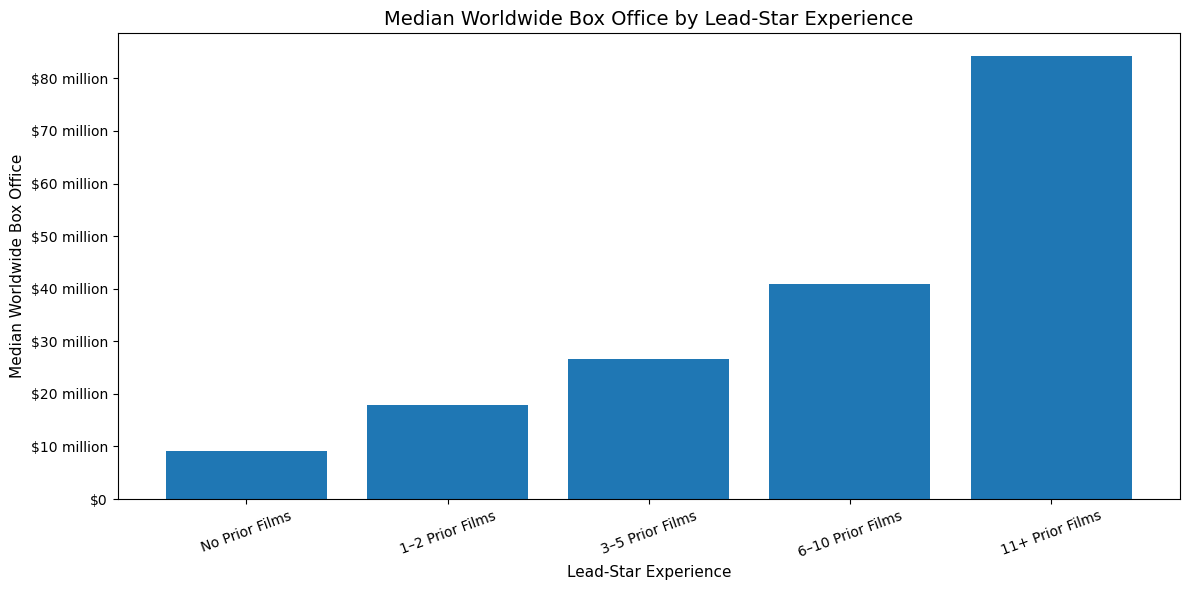

In [ ]:
star_experience = eda_movies.copy()

star_experience["star_experience_band"] = pd.cut(
    star_experience["star_prior_films"],
    bins=[
        -1,
        0,
        2,
        5,
        10,
        np.inf
    ],
    labels=[
        "No Prior Films",
        "1–2 Prior Films",
        "3–5 Prior Films",
        "6–10 Prior Films",
        "11+ Prior Films"
    ]
)

star_performance = (
    star_experience
    .groupby(
        "star_experience_band",
        observed=True
    )
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
)

print("=" * 80)
print("STAR EXPERIENCE PERFORMANCE")
print("=" * 80)

display(star_performance)


fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    star_performance[
        "star_experience_band"
    ].astype(str),
    star_performance[
        "median_box_office"
    ]
)

ax.set_title(
    "Median Worldwide Box Office by Lead-Star Experience",
    fontsize=14
)

ax.set_xlabel(
    "Lead-Star Experience",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 20. PRODUCTION COMPANY EXPERIENCE VS. BOX-OFFICE

,company_experience_band,movie_count,median_box_office,mean_box_office
0,No Prior Films,2480,6913694.0,3.256381e+07
1,1–10 Prior Films,2007,13273595.0,5.620502e+07
2,11–50 Prior Films,1201,29300090.0,8.075558e+07
3,51–100 Prior Films,576,47517590.0,1.090925e+08
4,101+ Prior Films,1215,113231078.0,1.923614e+08


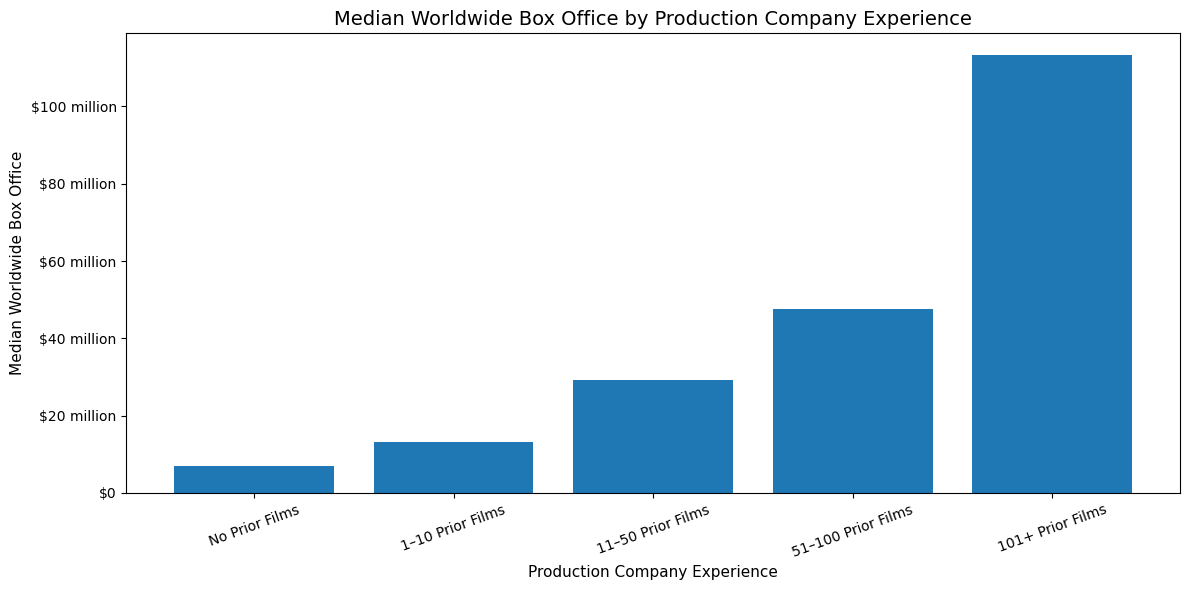

In [34]:
company_experience = eda_movies.copy()

company_experience["company_experience_band"] = pd.cut(
    company_experience["company_prior_films"],
    bins=[
        -1,
        0,
        10,
        50,
        100,
        np.inf
    ],
    labels=[
        "No Prior Films",
        "1–10 Prior Films",
        "11–50 Prior Films",
        "51–100 Prior Films",
        "101+ Prior Films"
    ]
)

company_performance = (
    company_experience
    .groupby(
        "company_experience_band",
        observed=True
    )
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
)

display(company_performance)


fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    company_performance["company_experience_band"].astype(str),
    company_performance["median_box_office"]
)

ax.set_title(
    "Median Worldwide Box Office by Production Company Experience",
    fontsize=14
)

ax.set_xlabel(
    "Production Company Experience",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 21. PRIOR AVERAGE GROSS VS. CURRENCT BOX-OFFICE

In [49]:
track_record_columns = {
    "Director": "director_prior_avg_gross",
    "Lead Star": "star_prior_avg_gross",
    "Production Company": "company_prior_avg_gross"
}

track_record_results = []

for entity, feature in track_record_columns.items():

    valid_data = (
        eda_movies[
            [
                feature,
                "worldwide_box_office"
            ]
        ]
        .dropna()
    )

    pearson_corr = (
        valid_data[feature]
        .corr(
            valid_data["worldwide_box_office"],
            method="pearson"
        )
    )

    spearman_corr = (
        valid_data[feature]
        .corr(
            valid_data["worldwide_box_office"],
            method="spearman"
        )
    )

    track_record_results.append({
        "entity": entity,
        "valid_movies": len(valid_data),
        "pearson_correlation": round(
            pearson_corr,
            3
        ),
        "spearman_correlation": round(
            spearman_corr,
            3
        )
    })


track_record_results = pd.DataFrame(
    track_record_results
)

print("=" * 80)
print("PRIOR AVERAGE GROSS RELATIONSHIPS")
print("=" * 80)

display(track_record_results)

PRIOR AVERAGE GROSS RELATIONSHIPS


,entity,valid_movies,pearson_correlation,spearman_correlation
0,Director,4607,0.539,0.575
1,Lead Star,4677,0.359,0.440
2,Production Company,4999,0.521,0.609


## 22. DIRECTOR PRIOR PERFORMANCE

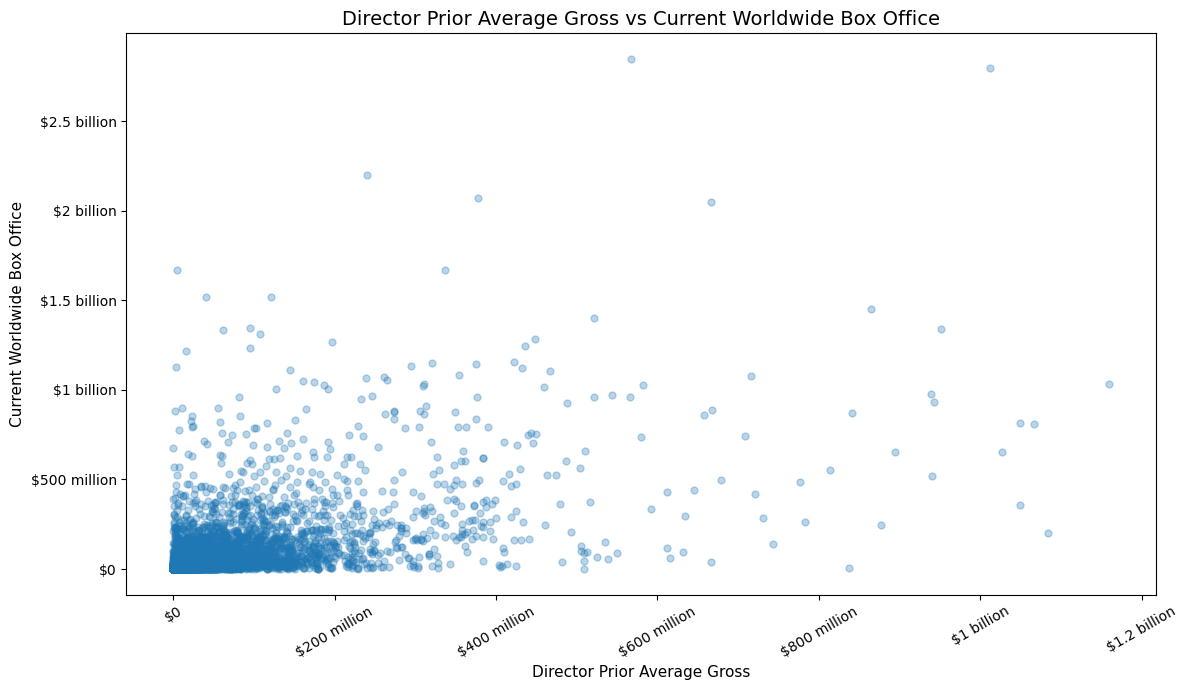

In [50]:
director_gross_data = (
    eda_movies[
        [
            "director_prior_avg_gross",
            "worldwide_box_office"
        ]
    ]
    .dropna()
)


fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    director_gross_data[
        "director_prior_avg_gross"
    ],
    director_gross_data[
        "worldwide_box_office"
    ],
    alpha=0.30,
    s=25
)

ax.set_title(
    "Director Prior Average Gross vs Current Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Director Prior Average Gross",
    fontsize=11
)

ax.set_ylabel(
    "Current Worldwide Box Office",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 23. LEAD-STAR PRIOR PERFORMANCE

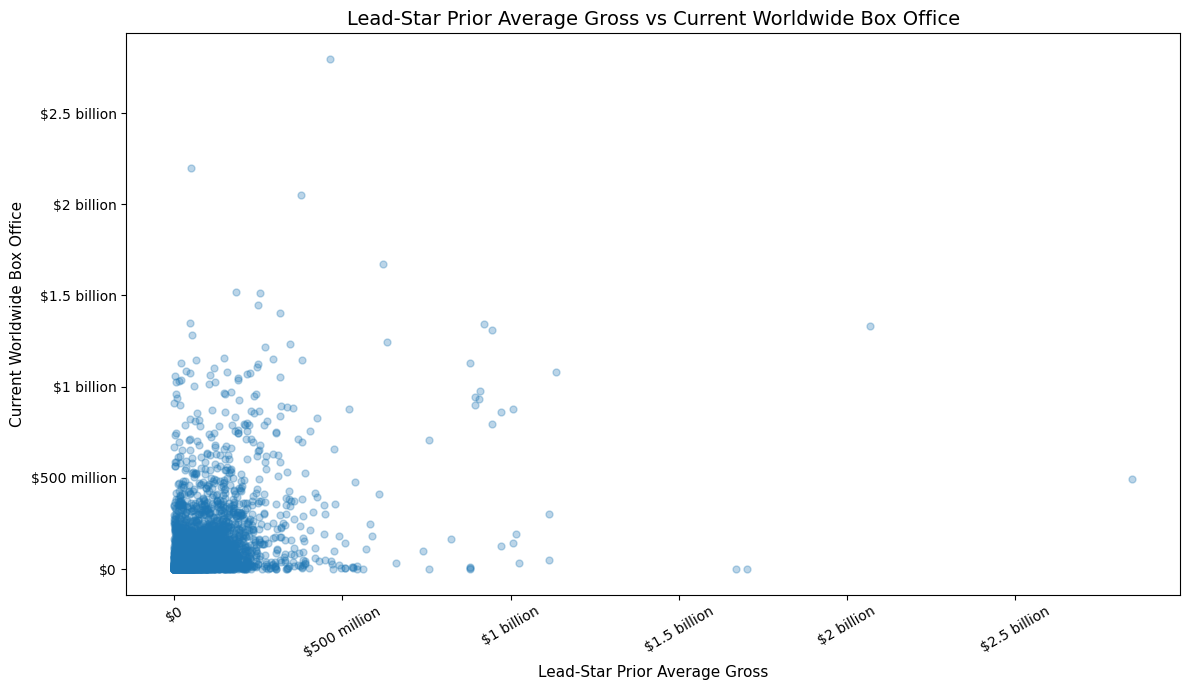

In [51]:
star_gross_data = (
    eda_movies[
        [
            "star_prior_avg_gross",
            "worldwide_box_office"
        ]
    ]
    .dropna()
)


fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    star_gross_data[
        "star_prior_avg_gross"
    ],
    star_gross_data[
        "worldwide_box_office"
    ],
    alpha=0.30,
    s=25
)

ax.set_title(
    "Lead-Star Prior Average Gross vs Current Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Lead-Star Prior Average Gross",
    fontsize=11
)

ax.set_ylabel(
    "Current Worldwide Box Office",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 24. PRODUCTION-COMPANY PRIOR PERFROMANCE

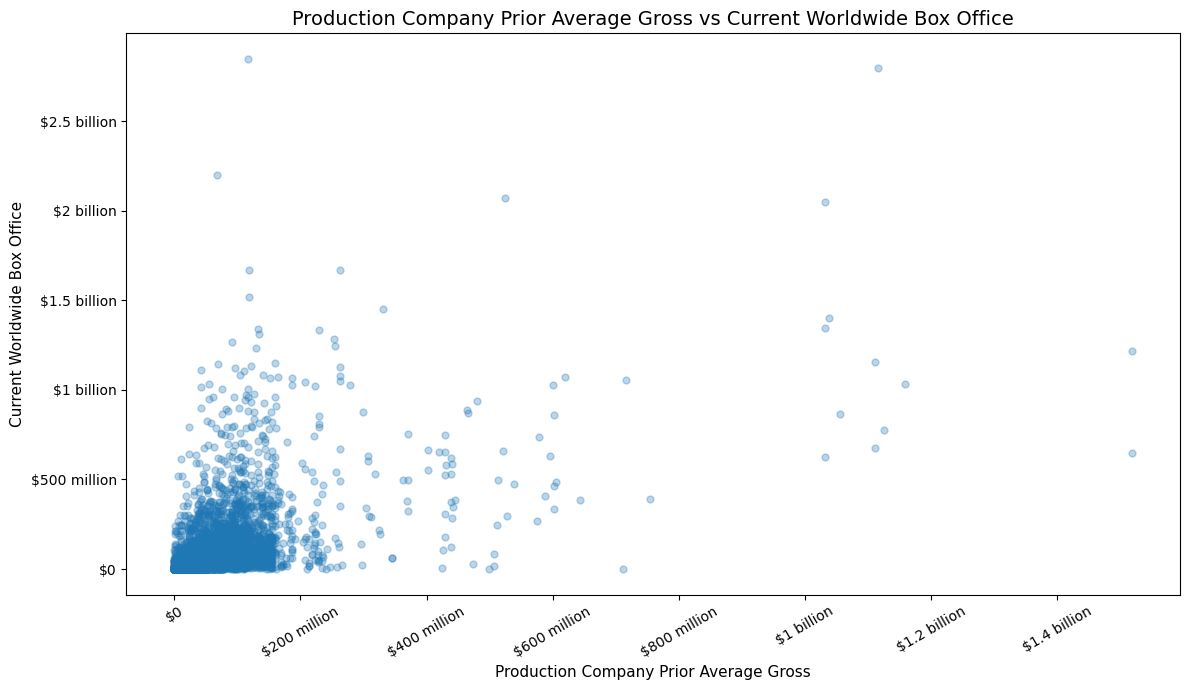

In [52]:
company_gross_data = (
    eda_movies[
        [
            "company_prior_avg_gross",
            "worldwide_box_office"
        ]
    ]
    .dropna()
)


fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    company_gross_data[
        "company_prior_avg_gross"
    ],
    company_gross_data[
        "worldwide_box_office"
    ],
    alpha=0.30,
    s=25
)

ax.set_title(
    "Production Company Prior Average Gross vs Current Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Production Company Prior Average Gross",
    fontsize=11
)

ax.set_ylabel(
    "Current Worldwide Box Office",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(format_money)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 25. NUMERICAL CORRELATION WITH THE REGRESSION TARGET

In [53]:
correlation_features = [
    "log_budget",

    "release_year",
    "release_month",
    "release_quarter",
    "holiday_release",

    "director_prior_films",
    "director_prior_avg_gross",

    "star_prior_films",
    "star_prior_avg_gross",

    "company_prior_films",
    "company_prior_avg_gross",

    "log_worldwide_box_office"
]

available_features = [
    column
    for column in correlation_features
    if column in eda_movies.columns
]

correlation_matrix = (
    eda_movies[available_features]
    .corr()
)

target_correlations = (
    correlation_matrix[
        "log_worldwide_box_office"
    ]
    .drop(
        "log_worldwide_box_office"
    )
    .sort_values(
        key=abs,
        ascending=False
    )
    .rename(
        "correlation_with_log_box_office"
    )
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)

print("=" * 80)
print("CORRELATION WITH LOG WORLDWIDE BOX OFFICE")
print("=" * 80)

display(target_correlations)

CORRELATION WITH LOG WORLDWIDE BOX OFFICE


,feature,correlation_with_log_box_office
0,log_budget,0.655071
1,director_prior_avg_gross,0.438794
2,company_prior_films,0.417941
3,company_prior_avg_gross,0.411049
4,star_prior_films,0.310351
5,star_prior_avg_gross,0.274572
6,release_year,0.247163
7,director_prior_films,0.242922
8,holiday_release,0.083862
9,release_month,0.032501


## 26. PREDICTOR CORRELATION MATRIX



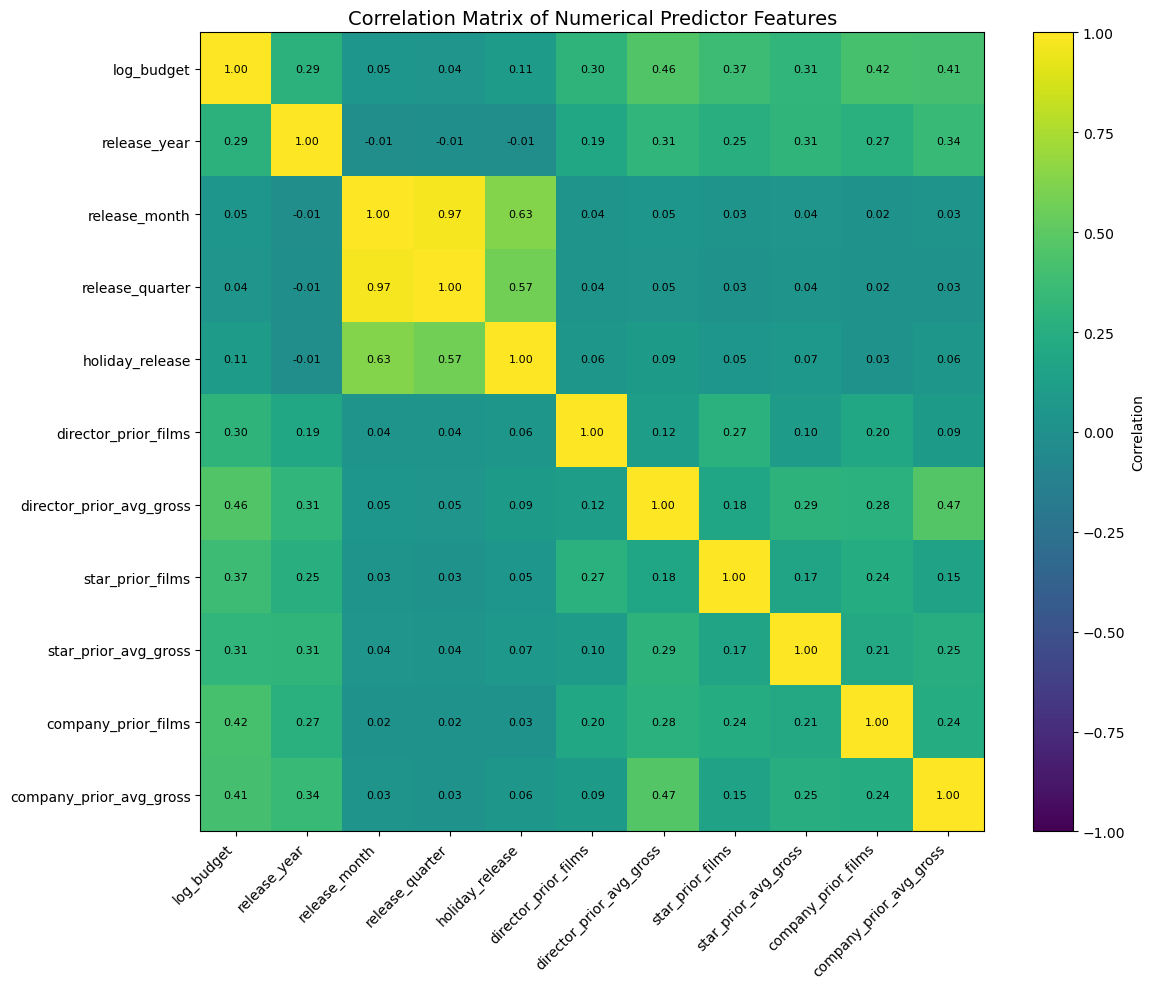

In [54]:
predictor_columns = [
    "log_budget",
    "release_year",
    "release_month",
    "release_quarter",
    "holiday_release",
    "director_prior_films",
    "director_prior_avg_gross",
    "star_prior_films",
    "star_prior_avg_gross",
    "company_prior_films",
    "company_prior_avg_gross"
]

predictor_columns = [
    col for col in predictor_columns
    if col in eda_movies.columns
]

predictor_corr = (
    eda_movies[predictor_columns]
    .corr()
)

fig, ax = plt.subplots(figsize=(12, 10))

image = ax.imshow(
    predictor_corr,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(
    range(len(predictor_columns))
)

ax.set_yticks(
    range(len(predictor_columns))
)

ax.set_xticklabels(
    predictor_columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    predictor_columns
)

ax.set_title(
    "Correlation Matrix of Numerical Predictor Features",
    fontsize=14
)

for i in range(len(predictor_columns)):
    for j in range(len(predictor_columns)):

        value = predictor_corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()
plt.show()

## 27. HIGH-CORRELATION PAIR AUDIT

In [55]:
high_corr_pairs = []

for i in range(len(predictor_corr.columns)):

    for j in range(i + 1, len(predictor_corr.columns)):

        feature_1 = predictor_corr.columns[i]
        feature_2 = predictor_corr.columns[j]

        correlation = (
            predictor_corr.iloc[i, j]
        )

        if abs(correlation) >= 0.70:

            high_corr_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlation": round(
                    correlation,
                    3
                )
            })


high_corr_pairs = pd.DataFrame(
    high_corr_pairs
)

print("=" * 80)
print("HIGH-CORRELATION PREDICTOR PAIRS")
print("=" * 80)

if len(high_corr_pairs) == 0:

    print(
        "\nNo predictor pairs with "
        "|correlation| >= 0.70."
    )

else:

    display(
        high_corr_pairs.sort_values(
            "correlation",
            key=abs,
            ascending=False
        )
    )

HIGH-CORRELATION PREDICTOR PAIRS


,feature_1,feature_2,correlation
0,release_month,release_quarter,0.972


## 28. TRACK-RECORD LEAKAGE SANITY CHECK

In [56]:
track_record_checks = {
    "Director": (
        "director_prior_films",
        "director_prior_avg_gross"
    ),
    "Lead Star": (
        "star_prior_films",
        "star_prior_avg_gross"
    ),
    "Production Company": (
        "company_prior_films",
        "company_prior_avg_gross"
    )
}

leakage_results = []

for entity, (count_col, gross_col) in track_record_checks.items():

    prior_count = eda_movies[count_col]
    prior_gross = eda_movies[gross_col]
    current_gross = eda_movies[
        "worldwide_box_office"
    ]

    exact_matches = (
        prior_gross.notna()
        &
        np.isclose(
            prior_gross,
            current_gross,
            rtol=1e-10,
            atol=1
        )
    )

    leakage_results.append({

        "entity": entity,

        "avg_present_with_zero_prior": (
            (prior_count == 0)
            & prior_gross.notna()
        ).sum(),

        "avg_missing_with_positive_prior": (
            (prior_count > 0)
            & prior_gross.isna()
        ).sum(),

        "prior_avg_equals_current_gross": (
            exact_matches.sum()
        )
    })


leakage_results = pd.DataFrame(
    leakage_results
)

print("=" * 80)
print("TRACK-RECORD LEAKAGE SANITY CHECK")
print("=" * 80)

display(leakage_results)

TRACK-RECORD LEAKAGE SANITY CHECK


,entity,avg_present_with_zero_prior,avg_missing_with_positive_prior,prior_avg_equals_current_gross
0,Director,0,0,0
1,Lead Star,0,0,0
2,Production Company,0,0,0


## 29. BOX-OFFICE TREND ACROSS TIME

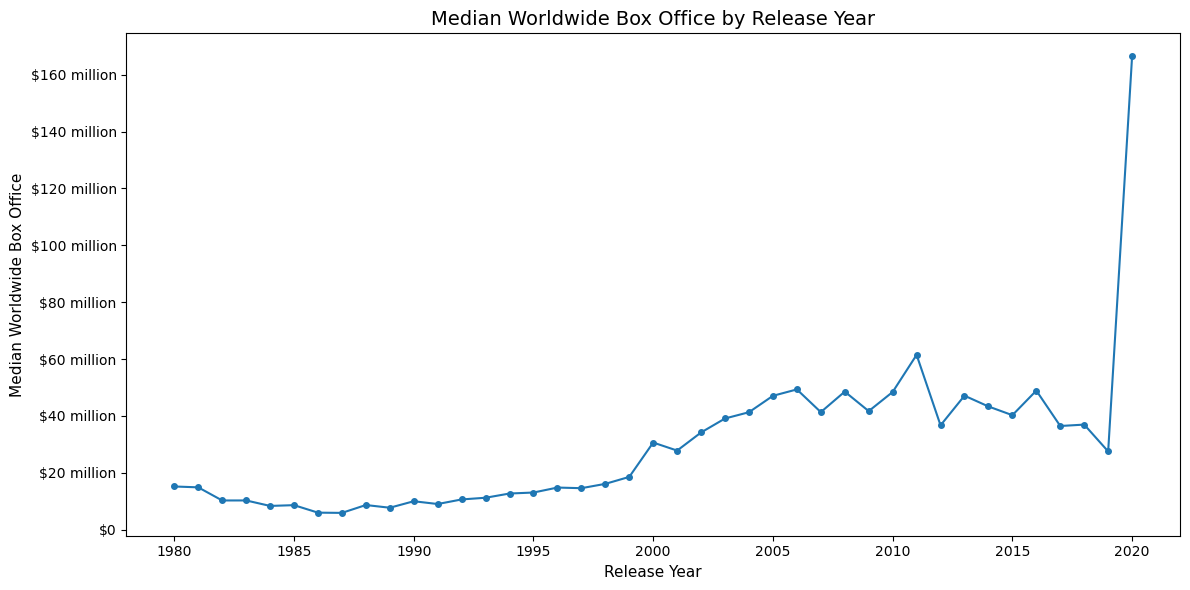

In [57]:
yearly_box_office = (
    eda_movies
    .groupby("release_year")
    .agg(
        movie_count=(
            "worldwide_box_office",
            "size"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        mean_box_office=(
            "worldwide_box_office",
            "mean"
        )
    )
    .reset_index()
)


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_box_office["release_year"],
    yearly_box_office["median_box_office"],
    marker="o",
    markersize=4
)

ax.set_title(
    "Median Worldwide Box Office by Release Year",
    fontsize=14
)

ax.set_xlabel(
    "Release Year",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 30. PRODUCTION BUDGET TREND BY RELEASE YEAR

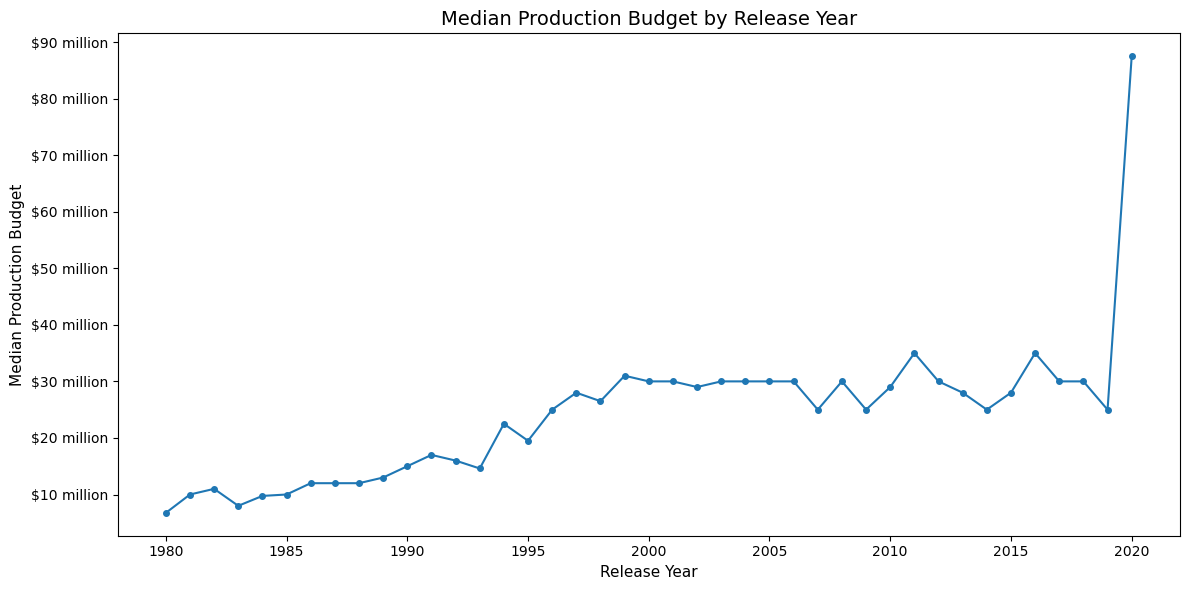

In [58]:
yearly_budget = (
    eda_movies
    .dropna(
        subset=[
            "release_year",
            "budget_usd"
        ]
    )
    .groupby("release_year")
    .agg(
        movie_count=(
            "budget_usd",
            "size"
        ),
        median_budget=(
            "budget_usd",
            "median"
        ),
        mean_budget=(
            "budget_usd",
            "mean"
        )
    )
    .reset_index()
)


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_budget["release_year"],
    yearly_budget["median_budget"],
    marker="o",
    markersize=4
)

ax.set_title(
    "Median Production Budget by Release Year",
    fontsize=14
)

ax.set_xlabel(
    "Release Year",
    fontsize=11
)

ax.set_ylabel(
    "Median Production Budget",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 31. YEARLY SAMPLE-SIZE AUDIT

In [59]:
yearly_sample_audit = (
    eda_movies
    .groupby("release_year")
    .agg(
        total_movies=(
            "worldwide_box_office",
            "size"
        ),
        movies_with_budget=(
            "budget_usd",
            "count"
        ),
        median_box_office=(
            "worldwide_box_office",
            "median"
        ),
        median_budget=(
            "budget_usd",
            "median"
        )
    )
    .reset_index()
)

print("=" * 80)
print("YEARLY SAMPLE-SIZE AUDIT")
print("=" * 80)

display(
    yearly_sample_audit.tail(10)
)

YEARLY SAMPLE-SIZE AUDIT


,release_year,total_movies,movies_with_budget,median_box_office,median_budget
31,2011,199,160,61487846.0,35000000.0
32,2012,200,163,36707760.5,30000000.0
33,2013,200,161,47131576.0,28000000.0
34,2014,200,163,43338802.0,25000000.0
35,2015,199,156,40272135.0,28000000.0
36,2016,200,159,48917728.5,35000000.0
37,2017,200,133,36469869.0,30000000.0
38,2018,200,143,36960410.0,30000000.0
39,2019,196,114,27526995.0,25000000.0
40,2020,15,8,166534027.0,87500000.0


## 32. INSPECT 2020 MOVIES

In [60]:
movies_2020 = (
    eda_movies[
        eda_movies["release_year"] == 2020
    ][
        [
            "title",
            "primary_genre",
            "budget_usd",
            "worldwide_box_office"
        ]
    ]
    .sort_values(
        "worldwide_box_office",
        ascending=False
    )
)

print("=" * 80)
print("2020 MOVIE AUDIT")
print("=" * 80)

print(
    f"\nNumber of 2020 movies: "
    f"{len(movies_2020):,}"
)

print(
    f"2020 movies with budget: "
    f"{movies_2020['budget_usd'].notna().sum():,}"
)

display(movies_2020)

2020 MOVIE AUDIT

Number of 2020 movies: 15
2020 movies with budget: 8


,title,primary_genre,budget_usd,worldwide_box_office
7473,The Eight Hundred,Action,8.000000e+07,461421559.0
7469,Bad Boys for Life,Action,9.000000e+07,426505244.0
7464,Tenet,Action,2.050000e+08,363656624.0
7470,Sonic the Hedgehog,Action,8.500000e+07,319715683.0
7471,Dolittle,Adventure,1.750000e+08,245487753.0
7475,Legend of Deification,Animation,NaN,240663149.0
7466,Birds of Prey,Action,8.450000e+07,201858461.0
7465,Wonder Woman 1984,Action,NaN,166534027.0
7467,The Invisible Man,Drama,7.000000e+06,143151000.0
7468,Onward,Animation,NaN,141950608.0


## 32A. RELIABLE YEARLY TREND FILTERS

In [64]:
MIN_MOVIES_PER_YEAR = 50

reliable_yearly_box_office = (
    yearly_sample_audit[
        yearly_sample_audit["total_movies"]
        >= MIN_MOVIES_PER_YEAR
    ]
    .copy()
)

reliable_yearly_budget = (
    yearly_sample_audit[
        (
            yearly_sample_audit["total_movies"]
            >= MIN_MOVIES_PER_YEAR
        )
        &
        (
            yearly_sample_audit["movies_with_budget"]
            >= MIN_MOVIES_PER_YEAR
        )
    ]
    .copy()
)

print("=" * 80)
print("RELIABLE TEMPORAL TREND SAMPLE")
print("=" * 80)

print(
    f"\nMinimum movies required per year: "
    f"{MIN_MOVIES_PER_YEAR}"
)

print(
    "\nYears excluded from box-office trend:"
)

print(
    yearly_sample_audit.loc[
        yearly_sample_audit["total_movies"]
        < MIN_MOVIES_PER_YEAR,
        ["release_year", "total_movies"]
    ]
)

print(
    "\nYears excluded from budget trend:"
)

print(
    yearly_sample_audit.loc[
        yearly_sample_audit["movies_with_budget"]
        < MIN_MOVIES_PER_YEAR,
        [
            "release_year",
            "movies_with_budget"
        ]
    ]
)

RELIABLE TEMPORAL TREND SAMPLE

Minimum movies required per year: 50

Years excluded from box-office trend:
    release_year  total_movies
40          2020            15

Years excluded from budget trend:
    release_year  movies_with_budget
0           1980                  40
40          2020                   8


## 32B. RELIABLE BOX-OFFICE TREND

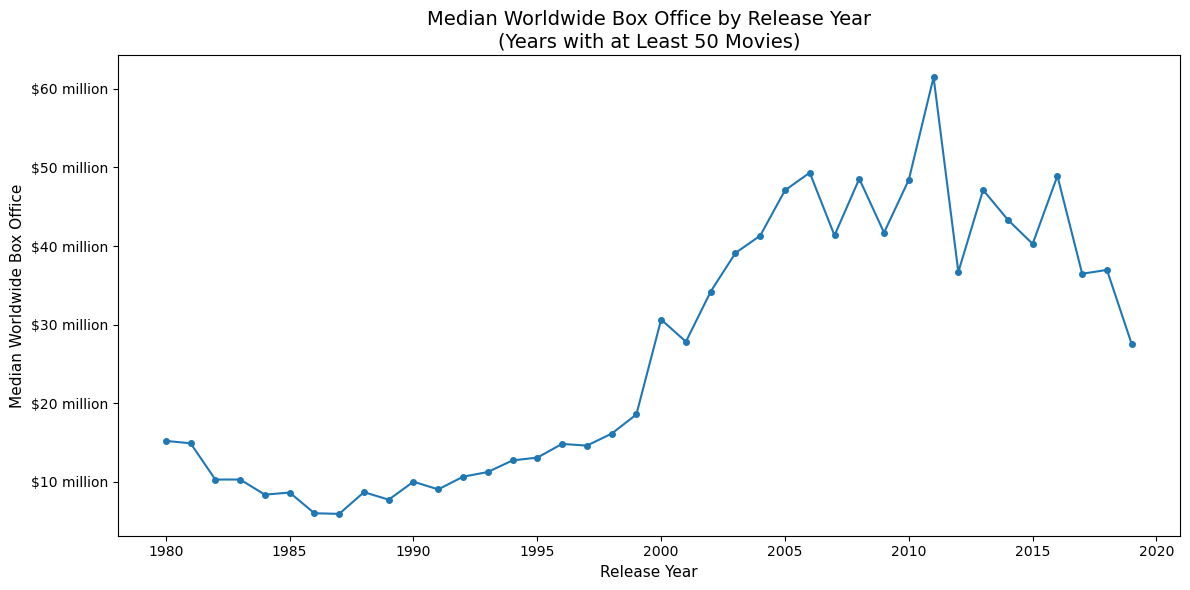

In [65]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    reliable_yearly_box_office["release_year"],
    reliable_yearly_box_office["median_box_office"],
    marker="o",
    markersize=4
)

ax.set_title(
    "Median Worldwide Box Office by Release Year\n"
    "(Years with at Least 50 Movies)",
    fontsize=14
)

ax.set_xlabel(
    "Release Year",
    fontsize=11
)

ax.set_ylabel(
    "Median Worldwide Box Office",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 32C. RELIABLE PRODUCTION BUDGET TREND

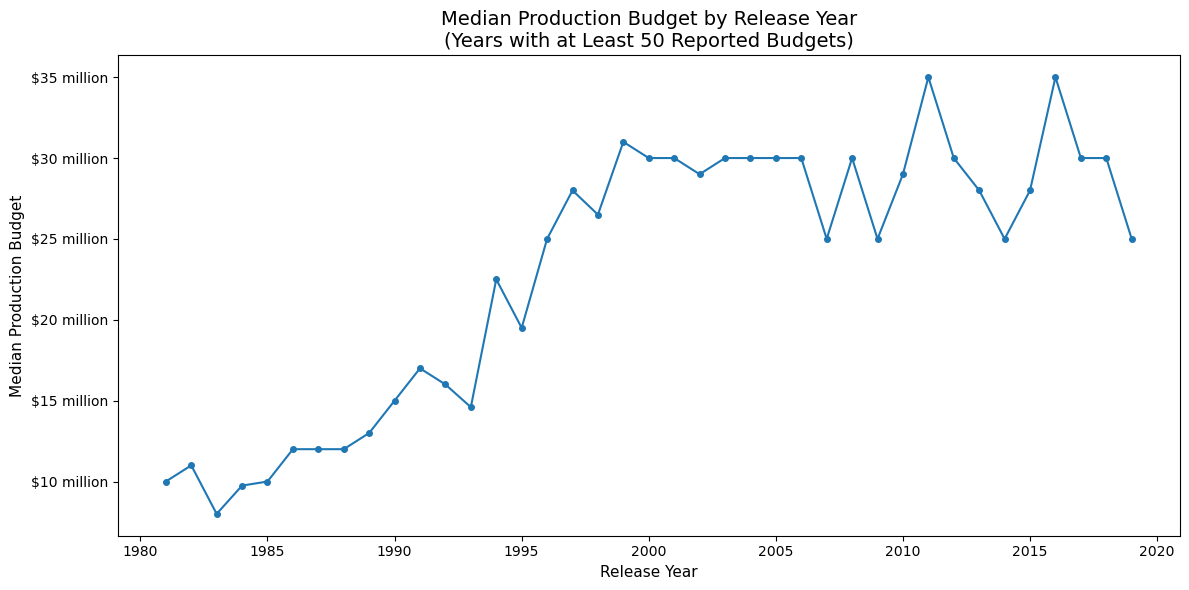

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    reliable_yearly_budget["release_year"],
    reliable_yearly_budget["median_budget"],
    marker="o",
    markersize=4
)

ax.set_title(
    "Median Production Budget by Release Year\n"
    "(Years with at Least 50 Reported Budgets)",
    fontsize=14
)

ax.set_xlabel(
    "Release Year",
    fontsize=11
)

ax.set_ylabel(
    "Median Production Budget",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

plt.tight_layout()
plt.show()

## 33. BUDGET COMPLETENESS BY YEAR RELEASE YEAR

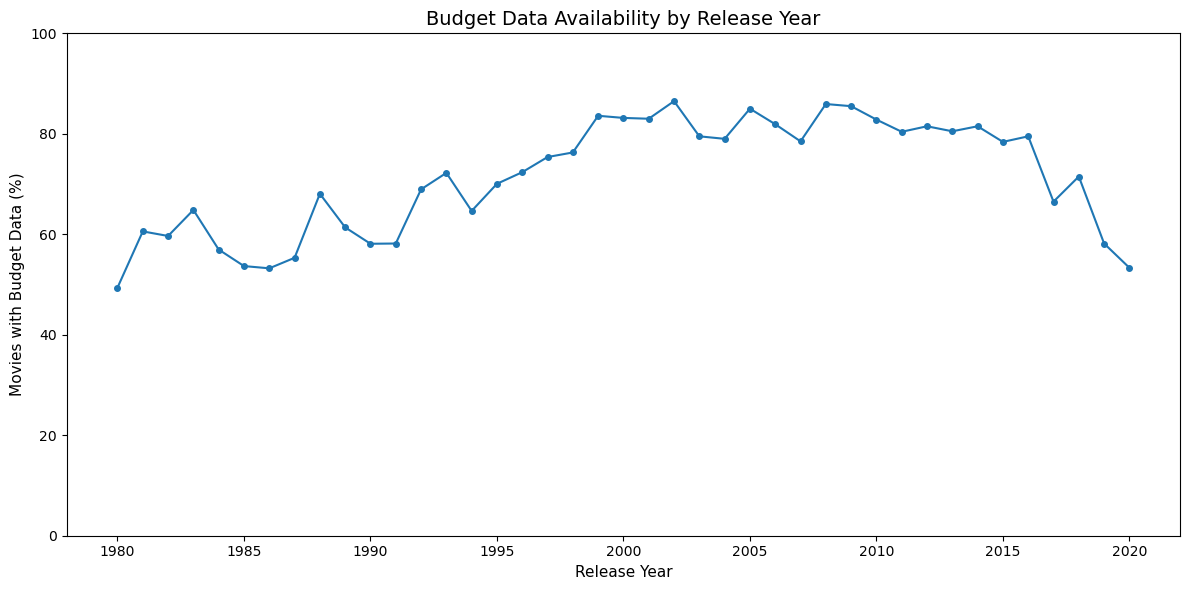

In [67]:
budget_completeness = (
    eda_movies
    .groupby("release_year")
    .agg(
        total_movies=(
            "title",
            "size"
        ),
        movies_with_budget=(
            "budget_usd",
            "count"
        )
    )
    .reset_index()
)

budget_completeness[
    "budget_available_percent"
] = (
    budget_completeness[
        "movies_with_budget"
    ]
    / budget_completeness[
        "total_movies"
    ]
    * 100
)


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    budget_completeness["release_year"],
    budget_completeness[
        "budget_available_percent"
    ],
    marker="o",
    markersize=4
)

ax.set_title(
    "Budget Data Availability by Release Year",
    fontsize=14
)

ax.set_xlabel(
    "Release Year",
    fontsize=11
)

ax.set_ylabel(
    "Movies with Budget Data (%)",
    fontsize=11
)

ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 34. EXTREME VALUE AUDIT


In [68]:
print("=" * 80)
print("HIGHEST WORLDWIDE BOX OFFICE")
print("=" * 80)

display(
    eda_movies[
        [
            "title",
            "release_year",
            "primary_genre",
            "budget_usd",
            "worldwide_box_office"
        ]
    ]
    .nlargest(
        15,
        "worldwide_box_office"
    )
)


print("\n" + "=" * 80)
print("HIGHEST PRODUCTION BUDGETS")
print("=" * 80)

display(
    eda_movies[
        [
            "title",
            "release_year",
            "primary_genre",
            "budget_usd",
            "worldwide_box_office"
        ]
    ]
    .nlargest(
        15,
        "budget_usd"
    )
)

HIGHEST WORLDWIDE BOX OFFICE


,title,release_year,primary_genre,budget_usd,worldwide_box_office
5274,Avatar,2009,Action,2.370000e+08,2.847246e+09
7270,Avengers: Endgame,2019,Action,3.560000e+08,2.797501e+09
2892,Titanic,1997,Drama,2.000000e+08,2.201647e+09
6489,Star Wars: Episode VII - The Force Awakens,2015,Action,2.450000e+08,2.069522e+09
7069,Avengers: Infinity War,2018,Action,3.210000e+08,2.048360e+09
7305,The Lion King,2019,Animation,2.600000e+08,1.670728e+09
6479,Jurassic World,2015,Action,1.500000e+08,1.670516e+09
5869,The Avengers,2012,Action,2.200000e+08,1.518816e+09
6472,Furious 7,2015,Action,1.900000e+08,1.515341e+09
7319,Frozen II,2019,Animation,1.500000e+08,1.450027e+09



HIGHEST PRODUCTION BUDGETS


,title,release_year,primary_genre,budget_usd,worldwide_box_office
7270,Avengers: Endgame,2019,Action,3.560000e+08,2.797501e+09
7069,Avengers: Infinity War,2018,Action,3.210000e+08,2.048360e+09
6900,Star Wars: Episode VIII - The Last Jedi,2017,Action,3.170000e+08,1.332699e+09
4890,Pirates of the Caribbean: at World's End,2007,Action,3.000000e+08,9.609965e+08
6891,Justice League,2017,Action,3.000000e+08,6.579270e+08
7086,Solo: A Star Wars Story,2018,Action,2.750000e+08,3.929248e+08
7288,Star Wars: Episode IX - The Rise of Skywalker,2019,Action,2.750000e+08,1.078233e+09
4701,Superman Returns,2006,Action,2.700000e+08,3.910812e+08
5487,Tangled,2010,Animation,2.600000e+08,5.924628e+08
7305,The Lion King,2019,Animation,2.600000e+08,1.670728e+09


## 35. LOG BUDGET VS. LOG WORLDWIDE BOX OFFICE

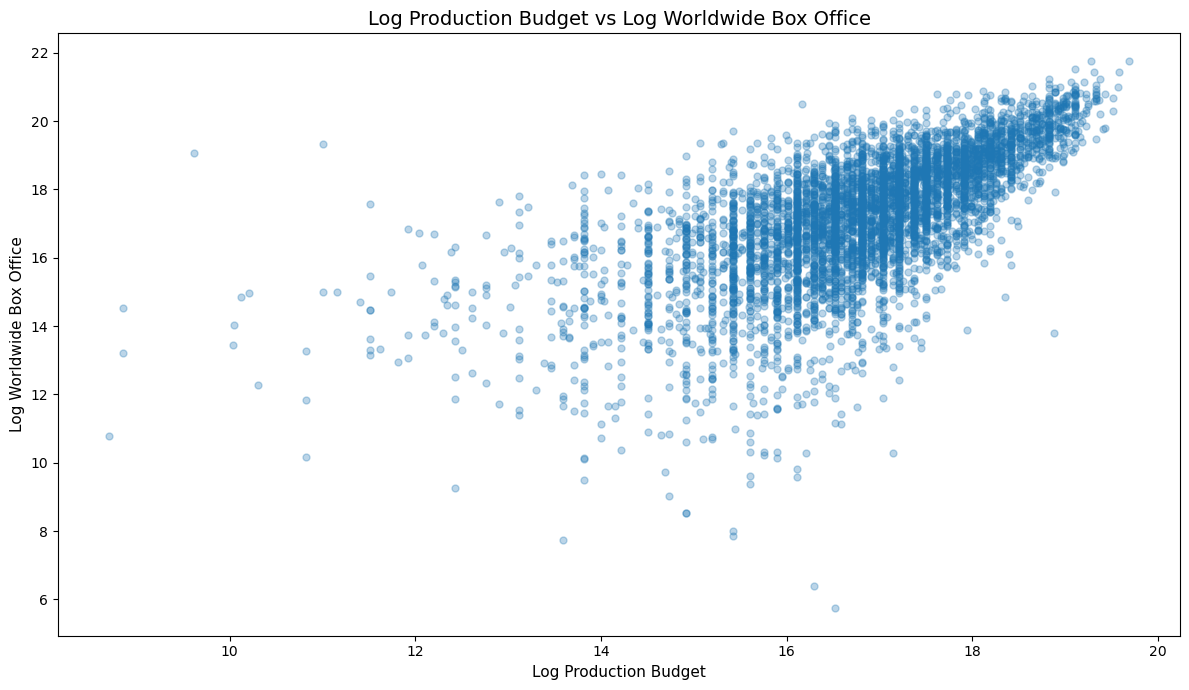

Log Budget ↔ Log Worldwide Box Office correlation: 0.655


In [69]:
log_relationship = (
    eda_movies[
        [
            "log_budget",
            "log_worldwide_box_office"
        ]
    ]
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    log_relationship["log_budget"],
    log_relationship[
        "log_worldwide_box_office"
    ],
    alpha=0.30,
    s=25
)

ax.set_title(
    "Log Production Budget vs Log Worldwide Box Office",
    fontsize=14
)

ax.set_xlabel(
    "Log Production Budget",
    fontsize=11
)

ax.set_ylabel(
    "Log Worldwide Box Office",
    fontsize=11
)

plt.tight_layout()
plt.show()


log_corr = (
    log_relationship["log_budget"]
    .corr(
        log_relationship[
            "log_worldwide_box_office"
        ]
    )
)

print(
    f"Log Budget ↔ Log Worldwide Box Office "
    f"correlation: {log_corr:.3f}"
)

## 36. BLOCKBUSTER TARGET DEFINITION AUDIT

In [70]:
box_office = eda_movies["worldwide_box_office"]

threshold_options = {
    "$100M+": 100_000_000,
    "$250M+": 250_000_000,
    "$500M+": 500_000_000,
    "$1B+": 1_000_000_000,
    "Top 20%": box_office.quantile(0.80),
    "Top 10%": box_office.quantile(0.90),
    "Top 5%": box_office.quantile(0.95)
}

blockbuster_audit = []

for definition, threshold in threshold_options.items():

    positive_count = (
        box_office >= threshold
    ).sum()

    negative_count = (
        box_office < threshold
    ).sum()

    positive_percent = (
        positive_count /
        len(box_office) * 100
    )

    blockbuster_audit.append({
        "definition": definition,
        "threshold_usd": threshold,
        "blockbusters": positive_count,
        "non_blockbusters": negative_count,
        "blockbuster_percent": positive_percent
    })


blockbuster_audit = pd.DataFrame(
    blockbuster_audit
)

blockbuster_audit[
    "blockbuster_percent"
] = (
    blockbuster_audit[
        "blockbuster_percent"
    ]
    .round(2)
)

print("=" * 80)
print("BLOCKBUSTER TARGET DEFINITION AUDIT")
print("=" * 80)

display(blockbuster_audit)

BLOCKBUSTER TARGET DEFINITION AUDIT


,definition,threshold_usd,blockbusters,non_blockbusters,blockbuster_percent
0,$100M+,1.000000e+08,1525,5954,20.39
1,$250M+,2.500000e+08,594,6885,7.94
2,$500M+,5.000000e+08,207,7272,2.77
3,$1B+,1.000000e+09,48,7431,0.64
4,Top 20%,1.018482e+08,1496,5983,20.00
5,Top 10%,2.090678e+08,748,6731,10.00
6,Top 5%,3.528074e+08,374,7105,5.00


## 37. FINAL MISSING-DATA DECISION TABLE

In [71]:
missing_decisions = pd.DataFrame({
    "feature": [
        "log_budget",
        "director_prior_avg_gross",
        "star_prior_avg_gross",
        "company_prior_avg_gross",
        "release_month",
        "release_quarter",
        "release_date"
    ],

    "missing_count": [
        eda_movies["log_budget"].isna().sum(),
        eda_movies["director_prior_avg_gross"].isna().sum(),
        eda_movies["star_prior_avg_gross"].isna().sum(),
        eda_movies["company_prior_avg_gross"].isna().sum(),
        eda_movies["release_month"].isna().sum(),
        eda_movies["release_quarter"].isna().sum(),
        eda_movies["release_date"].isna().sum()
    ],

    "missing_percent": [
        eda_movies["log_budget"].isna().mean() * 100,
        eda_movies["director_prior_avg_gross"].isna().mean() * 100,
        eda_movies["star_prior_avg_gross"].isna().mean() * 100,
        eda_movies["company_prior_avg_gross"].isna().mean() * 100,
        eda_movies["release_month"].isna().mean() * 100,
        eda_movies["release_quarter"].isna().mean() * 100,
        eda_movies["release_date"].isna().mean() * 100
    ],

    "eda_interpretation": [
        "Genuine missing budget data",
        "Structural when director has no prior films",
        "Structural when lead star has no prior films",
        "Structural when company has no prior films",
        "Small genuine missingness",
        "Small genuine missingness",
        "Small genuine missingness"
    ]
})

missing_decisions[
    "missing_percent"
] = (
    missing_decisions[
        "missing_percent"
    ]
    .round(2)
)

display(missing_decisions)

,feature,missing_count,missing_percent,eda_interpretation
0,log_budget,2043,27.32,Genuine missing budget data
1,director_prior_avg_gross,2872,38.40,Structural when director has no prior films
2,star_prior_avg_gross,2802,37.46,Structural when lead star has no prior films
3,company_prior_avg_gross,2480,33.16,Structural when company has no prior films
4,release_month,49,0.66,Small genuine missingness
5,release_quarter,49,0.66,Small genuine missingness
6,release_date,49,0.66,Small genuine missingness


## 38. RARE GENRE AUDIT

In [72]:
genre_model_audit = (
    eda_movies["primary_genre"]
    .value_counts()
    .rename_axis("primary_genre")
    .reset_index(name="movie_count")
)

genre_model_audit[
    "dataset_percent"
] = (
    genre_model_audit[
        "movie_count"
    ]
    / len(eda_movies)
    * 100
).round(2)

genre_model_audit[
    "rare_under_50_movies"
] = (
    genre_model_audit[
        "movie_count"
    ] < 50
)

print("=" * 80)
print("GENRE MODEL-READINESS AUDIT")
print("=" * 80)

display(genre_model_audit)

GENRE MODEL-READINESS AUDIT


,primary_genre,movie_count,dataset_percent,rare_under_50_movies
0,Comedy,2192,29.31,False
1,Action,1673,22.37,False
2,Drama,1468,19.63,False
3,Crime,542,7.25,False
4,Biography,433,5.79,False
5,Adventure,420,5.62,False
6,Animation,335,4.48,False
7,Horror,307,4.10,False
8,Fantasy,43,0.57,True
9,Mystery,20,0.27,True


## 39. FINAL EDA FINDINGS

In [73]:
eda_findings = pd.DataFrame({
    "area": [
        "Regression Target",
        "Budget",
        "Genre",
        "Release Timing",
        "Director Track Record",
        "Lead-Star Track Record",
        "Company Track Record",
        "Temporal Variables",
        "Redundant Features",
        "Outliers",
        "Data Leakage",
        "Missing Data"
    ],

    "finding": [
        "Worldwide box office is highly right-skewed.",
        "Budget is the strongest individual numerical predictor observed.",
        "Genre shows meaningful differences in typical box-office performance.",
        "Month and holiday timing show useful non-linear/categorical effects.",
        "Director prior success and experience are associated with higher revenue.",
        "Lead-star experience and prior gross show positive associations.",
        "Company experience and prior gross show strong associations.",
        "Revenue and budget vary substantially across historical periods.",
        "Release month and release quarter are highly correlated.",
        "Extreme blockbusters appear to be legitimate observations.",
        "Track-record features passed the basic leakage sanity check.",
        "Budget missingness is genuine and varies over time; track-record missingness is largely structural."
    ],

    "modelling_implication": [
        "Use log_worldwide_box_office as primary regression target.",
        "Retain log_budget and handle missing values during preprocessing.",
        "Retain primary_genre; consider grouping very rare genres.",
        "Treat release timing categorically/cyclically rather than as purely linear.",
        "Retain director track-record features.",
        "Retain lead-star track-record features.",
        "Retain company track-record features.",
        "Use time-aware validation and investigate training-period recency.",
        "Prefer release_month; consider dropping release_quarter.",
        "Do not remove valid blockbusters merely because they are extreme.",
        "Proceed, while preserving chronological feature construction.",
        "Do not perform blanket row deletion."
    ]
})

print("=" * 80)
print("FINAL EDA FINDINGS AND MODELLING IMPLICATIONS")
print("=" * 80)

display(eda_findings)

FINAL EDA FINDINGS AND MODELLING IMPLICATIONS


,area,finding,modelling_implication
0,Regression Target,Worldwide box office is highly right-skewed.,Use log_worldwide_box_office as primary regres...
1,Budget,Budget is the strongest individual numerical p...,Retain log_budget and handle missing values du...
2,Genre,Genre shows meaningful differences in typical ...,Retain primary_genre; consider grouping very r...
3,Release Timing,Month and holiday timing show useful non-linea...,Treat release timing categorically/cyclically ...
4,Director Track Record,Director prior success and experience are asso...,Retain director track-record features.
5,Lead-Star Track Record,Lead-star experience and prior gross show posi...,Retain lead-star track-record features.
6,Company Track Record,Company experience and prior gross show strong...,Retain company track-record features.
7,Temporal Variables,Revenue and budget vary substantially across h...,Use time-aware validation and investigate trai...
8,Redundant Features,Release month and release quarter are highly c...,Prefer release_month; consider dropping releas...
9,Outliers,Extreme blockbusters appear to be legitimate o...,Do not remove valid blockbusters merely becaus...
